# 05 — GC Perturbation Engine

Multi-dimensional phase-space response of a GD-1-like stellar stream to a
globular-cluster (GC) perturber.

This notebook follows the validated GMC perturbation framework from Notebook 04.

## Physical comparison

### Canonical DM

- **Mass:** $M = 10^7\,M_\odot$
- **Plummer scale:** $a = 0.5$ kpc
- **Impact parameter:** $b = 0.5$ kpc

### GC sweep

Compact Plummer perturbers matched to the canonical DM impulse scale.

## Common encounter conditions

- **Relative velocity:** $v_{\rm rel} = 300$ km/s
- **Encounter time:** $t_{\rm encounter} = -500$ Myr

## Numerical configuration

- **Particles:** $N = 192{,}064$
- **Integration timestep:** $dt = 0.5$ Myr
- **Release cadence:** 0.5 Myr

## Workflow

$$
\text{parameter design}
\;\longrightarrow\;
\text{encounter geometry}
\;\longrightarrow\;
\text{native DirectNBody smoke tests}
$$

$$
\longrightarrow\;
\text{production GC streams}
\;\longrightarrow\;
\text{matched controls}
\;\longrightarrow\;
\text{phase-space responses}
$$

$$
\longrightarrow\;
\text{density responses}
\;\longrightarrow\;
\text{GC fingerprints}
\;\longrightarrow\;
\text{DM / GMC / GC comparison}
$$

In [66]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

import astropy.units as u

from astropy.coordinates import (
    SkyCoord,
    Galactocentric,
    ICRS,
)

import gala.dynamics as gd
import gala.potential as gp

from gala.dynamics.nbody import DirectNBody
from gala.coordinates import GD1Koposov10

from gala.dynamics import mockstream as ms

import matplotlib.pyplot as plt

print("Imports: PASS")

Imports: PASS


In [2]:
# ============================================================
# Project configuration
# ============================================================

PROJECT_ROOT = Path.cwd().parent

assert PROJECT_ROOT.name == "stellar_streams", (
    f"Unexpected project root: {PROJECT_ROOT}"
)

DATA_DIR = PROJECT_ROOT / "data"
DERIVED_DIR = DATA_DIR / "derived"

S0_DIR = DERIVED_DIR / "s0"
DM_DIR = DERIVED_DIR / "dm_fingerprint_192k"
GMC_DIR = DERIVED_DIR / "gmc_fingerprint_192k"

GC_DIR = DERIVED_DIR / "gc_fingerprint_192k"

S0_FILE = S0_DIR / "S0_particles.npz"
S0_META_FILE = S0_DIR / "S0_metadata.json"

print("Project configuration:")
print("  PROJECT_ROOT =", PROJECT_ROOT)
print("  S0_DIR      =", S0_DIR)
print("  S0_FILE     =", S0_FILE)
print("  S0 metadata =", S0_META_FILE)
print("  GC output   =", GC_DIR)

assert S0_DIR.exists()
assert S0_FILE.exists()
assert S0_META_FILE.exists()

print("\nS0 files: PASS")

Project configuration:
  PROJECT_ROOT = /home/darxsouls/research/stellar_streams
  S0_DIR      = /home/darxsouls/research/stellar_streams/data/derived/s0
  S0_FILE     = /home/darxsouls/research/stellar_streams/data/derived/s0/S0_particles.npz
  S0 metadata = /home/darxsouls/research/stellar_streams/data/derived/s0/S0_metadata.json
  GC output   = /home/darxsouls/research/stellar_streams/data/derived/gc_fingerprint_192k

S0 files: PASS


In [3]:
# ============================================================
# Global numerical configuration
# ============================================================

DT = 0.5 * u.Myr
RELEASE_CADENCE = 0.5 * u.Myr
T_STRIP = 1500.0 * u.Myr

N_PARTICLES = 192_064

RNG_SEED = 314159

# ------------------------------------------------------------
# GD-1 / progenitor configuration
# ------------------------------------------------------------

ANCHOR_PHI1 = -30.0 * u.deg
ANCHOR_PHI2 = 0.0931 * u.deg
ANCHOR_DISTANCE = 7.62 * u.kpc
ANCHOR_PM1 = -12.7801 * u.mas / u.yr
ANCHOR_PM2 = -3.0048 * u.mas / u.yr
ANCHOR_RV = -86.56 * u.km / u.s

M_PROG = 2.0e4 * u.Msun
R_HALF = 20.0 * u.pc

PLUMMER_B = R_HALF / 1.30476603

# ------------------------------------------------------------
# Milky Way potential
# ------------------------------------------------------------

mw = gp.MilkyWayPotential(version="v2")

print("Configuration: PASS")
print("  N particles:", N_PARTICLES)
print("  dt:", DT)
print("  release cadence:", RELEASE_CADENCE)
print("  T_strip:", T_STRIP)
print("  progenitor mass:", M_PROG)
print("  progenitor r_half:", R_HALF)

Configuration: PASS
  N particles: 192064
  dt: 0.5 Myr
  release cadence: 0.5 Myr
  T_strip: 1500.0 Myr
  progenitor mass: 20000.0 solMass
  progenitor r_half: 20.0 pc


In [4]:
# ============================================================
# GC parameter-space design
# ============================================================

DM_MASS = 1.0e7 * u.Msun
DM_SCALE = 0.5 * u.kpc
DM_IMPACT_PARAMETER = 0.5 * u.kpc

GC_REL_SPEED = 300.0 * u.km / u.s
GC_T_ENCOUNTER = -500.0 * u.Myr

# ------------------------------------------------------------
# Canonical DM impulse scale
# ------------------------------------------------------------

def impulse_scale(M, b, a):
    M_val = M.to_value(u.Msun)
    b_val = b.to_value(u.kpc)
    a_val = a.to_value(u.kpc)

    return M_val * b_val / (b_val**2 + a_val**2)


I_DM = impulse_scale(
    DM_MASS,
    DM_IMPACT_PARAMETER,
    DM_SCALE,
)

print("Canonical DM impulse scale:")
print(f"  I_DM = {I_DM:.8e}")

Canonical DM impulse scale:
  I_DM = 1.00000000e+07


In [5]:
# ============================================================
# Solve matched-impulse GC impact parameter
# ============================================================

def matched_impact_parameter(M, a, I_target):
    """
    Solve

        I_target = M*b / (b^2 + a^2)

    for b.

    Returns the larger positive solution.
    """

    M_val = M.to_value(u.Msun)
    a_val = a.to_value(u.kpc)

    discriminant = (
        M_val**2
        - 4.0 * I_target**2 * a_val**2
    )

    if discriminant < 0:
        return None

    sqrt_disc = np.sqrt(discriminant)

    b_large = (
        M_val + sqrt_disc
    ) / (2.0 * I_target)

    return b_large * u.kpc


GC_DESIGN = [
    ("G1", 5.0e5 * u.Msun, 0.005 * u.kpc),
    ("G2", 1.0e6 * u.Msun, 0.005 * u.kpc),
    ("G3", 1.0e6 * u.Msun, 0.010 * u.kpc),
    ("G4", 2.0e6 * u.Msun, 0.010 * u.kpc),
    ("G5", 2.0e6 * u.Msun, 0.020 * u.kpc),
]

print("=" * 92)
print("GC PARAMETER-SPACE DESIGN")
print("=" * 92)

print(
    f"Target DM impulse scale = {I_DM:.8e}"
)

print()
print(
    f"{'Case':<8}"
    f"{'M_GC [Msun]':>15}"
    f"{'a [kpc]':>12}"
    f"{'b_match [kpc]':>18}"
    f"{'I/I_DM':>14}"
    f"{'Status':>12}"
)

print("-" * 92)

GC_SWEEP = []

for case, mass, scale in GC_DESIGN:

    b_match = matched_impact_parameter(
        mass,
        scale,
        I_DM,
    )

    if b_match is None:

        print(
            f"{case:<8}"
            f"{mass.to_value(u.Msun):>15.2e}"
            f"{scale.to_value(u.kpc):>12.5f}"
            f"{'---':>18}"
            f"{'---':>14}"
            f"{'INVALID':>12}"
        )

        continue

    I_gc = impulse_scale(
        mass,
        b_match,
        scale,
    )

    ratio = I_gc / I_DM

    print(
        f"{case:<8}"
        f"{mass.to_value(u.Msun):>15.2e}"
        f"{scale.to_value(u.kpc):>12.5f}"
        f"{b_match.to_value(u.kpc):>18.5f}"
        f"{ratio:>14.8f}"
        f"{'MATCHED':>12}"
    )

    GC_SWEEP.append({
        "case": case,
        "mass": mass,
        "scale": scale,
        "impact_parameter": b_match,
        "impulse_ratio": ratio,
    })

assert len(GC_SWEEP) == 5

print()
print("GC parameter-space design: PASS")

GC PARAMETER-SPACE DESIGN
Target DM impulse scale = 1.00000000e+07

Case        M_GC [Msun]     a [kpc]     b_match [kpc]        I/I_DM      Status
--------------------------------------------------------------------------------------------
G1             5.00e+05     0.00500           0.04949    1.00000000     MATCHED
G2             1.00e+06     0.00500           0.09975    1.00000000     MATCHED
G3             1.00e+06     0.01000           0.09899    1.00000000     MATCHED
G4             2.00e+06     0.01000           0.19950    1.00000000     MATCHED
G5             2.00e+06     0.02000           0.19798    1.00000000     MATCHED

GC parameter-space design: PASS


In [6]:
# ============================================================
# Progenitor present-day phase-space state
# ============================================================

gd1_frame = GD1Koposov10()

gd1_anchor_stream = SkyCoord(
    phi1=ANCHOR_PHI1,
    phi2=ANCHOR_PHI2,
    distance=ANCHOR_DISTANCE,
    pm_phi1_cosphi2=ANCHOR_PM1,
    pm_phi2=ANCHOR_PM2,
    radial_velocity=ANCHOR_RV,
    frame=gd1_frame,
)

gd1_anchor_gc_obs = (
    gd1_anchor_stream
    .transform_to(ICRS())
    .transform_to(Galactocentric())
)

w_prog = gd.PhaseSpacePosition(
    pos=gd1_anchor_gc_obs.cartesian.xyz,
    vel=gd1_anchor_gc_obs.velocity.d_xyz,
)

prog_pos = w_prog.pos.xyz.to_value(u.kpc)
prog_vel = w_prog.vel.d_xyz.to_value(u.km / u.s)

print("Present-day progenitor state:")
print("  position =", prog_pos, "kpc")
print("  velocity =", prog_vel, "km/s")

assert np.isfinite(prog_pos).all()
assert np.isfinite(prog_vel).all()

print("\nProgenitor phase-space construction: PASS")

Present-day progenitor state:
  position = [-12.2139463    0.48129407   6.43083226] kpc
  velocity = [ -73.66232563 -212.19536319 -116.00466531] km/s

Progenitor phase-space construction: PASS


In [7]:
# ============================================================
# GC encounter progenitor state
# ============================================================

prog_back = mw.integrate_orbit(
    w_prog,
    dt=-DT,
    t1=0 * u.Myr,
    t2=GC_T_ENCOUNTER,
)

prog_enc = prog_back[-1]

r_prog_enc = prog_enc.pos.xyz.to_value(u.kpc)
v_prog_enc = prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

assert np.isfinite(r_prog_enc).all()
assert np.isfinite(v_prog_enc).all()

print("Progenitor at nominal GC encounter:")
print("  time =", GC_T_ENCOUNTER)
print("  r    =", r_prog_enc, "kpc")
print("  v    =", v_prog_enc, "kpc/Myr")

vhat_prog = v_prog_enc / np.linalg.norm(v_prog_enc)

assert np.isfinite(vhat_prog).all()
assert np.isclose(np.linalg.norm(vhat_prog), 1.0)

print("\nProgenitor velocity unit vector:")
print(" ", vhat_prog)

print("\nGC encounter progenitor state: PASS")

Progenitor at nominal GC encounter:
  time = -500.0 Myr
  r    = [-15.70989468   2.75688878  11.40195503] kpc
  v    = [-0.04125444 -0.16379049 -0.07420633] kpc/Myr

Progenitor velocity unit vector:
  [-0.2236158  -0.88781094 -0.40222843]

GC encounter progenitor state: PASS


In [8]:
# ============================================================
# GC encounter geometry basis
# ============================================================

# ------------------------------------------------------------
# Reference vector
# ------------------------------------------------------------

ref = np.array([0.0, 0.0, 1.0])

if abs(np.dot(ref, vhat_prog)) > 0.9:
    ref = np.array([0.0, 1.0, 0.0])

# ------------------------------------------------------------
# Impact-parameter direction
# ------------------------------------------------------------

bhat = ref - np.dot(ref, vhat_prog) * vhat_prog
bhat /= np.linalg.norm(bhat)

assert np.isfinite(bhat).all()
assert np.isclose(np.linalg.norm(bhat), 1.0)
assert np.isclose(
    np.dot(bhat, vhat_prog),
    0.0,
    atol=1e-12,
)

# ------------------------------------------------------------
# Relative velocity direction
# ------------------------------------------------------------

vhat_rel = np.cross(vhat_prog, bhat)
vhat_rel /= np.linalg.norm(vhat_rel)

assert np.isfinite(vhat_rel).all()
assert np.isclose(np.linalg.norm(vhat_rel), 1.0)
assert np.isclose(
    np.dot(vhat_rel, vhat_prog),
    0.0,
    atol=1e-12,
)
assert np.isclose(
    np.dot(vhat_rel, bhat),
    0.0,
    atol=1e-12,
)

print("Encounter basis:")
print("  v_hat_prog =", vhat_prog)
print("  b_hat      =", bhat)
print("  v_hat_rel  =", vhat_rel)

print("\nOrthogonality checks:")
print("  b · v_prog =", np.dot(bhat, vhat_prog))
print("  v_rel · v_prog =", np.dot(vhat_rel, vhat_prog))
print("  v_rel · b =", np.dot(vhat_rel, bhat))

print("\nGC encounter basis: PASS")

Encounter basis:
  v_hat_prog = [-0.2236158  -0.88781094 -0.40222843]
  b_hat      = [-0.09824224 -0.39004637  0.91553934]
  v_hat_rel  = [-0.96971359  0.24424488  0.        ]

Orthogonality checks:
  b · v_prog = 2.706518080825311e-17
  v_rel · v_prog = -8.345586645035912e-18
  v_rel · b = 3.839342161336312e-18

GC encounter basis: PASS


In [9]:
# ============================================================
# GC encounter-state constructor
# ============================================================

def construct_gc_encounter(
    mass,
    scale,
    impact_parameter,
    t_encounter=GC_T_ENCOUNTER,
    relative_speed=GC_REL_SPEED,
):
    """
    Construct a GC phase-space state at the nominal encounter.

    The GC is placed at the requested impact parameter from
    the progenitor and given the requested relative velocity.

    Geometry:

        r_GC = r_prog + b * b_hat

        v_GC = v_prog + v_rel
    """

    # --------------------------------------------------------
    # Position
    # --------------------------------------------------------

    b_kpc = impact_parameter.to_value(u.kpc)

    r_gc_enc = (
        r_prog_enc
        + b_kpc * bhat
    )

    # --------------------------------------------------------
    # Relative velocity
    # --------------------------------------------------------

    vrel_kpcmyr = relative_speed.to_value(
        u.kpc / u.Myr
    )

    v_rel = vrel_kpcmyr * vhat_rel

    v_gc_enc = (
        v_prog_enc
        + v_rel
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    delta_r = r_gc_enc - r_prog_enc
    delta_v = v_gc_enc - v_prog_enc

    constructed_b = (
        np.linalg.norm(delta_r) * u.kpc
    )

    constructed_vrel = (
        np.linalg.norm(delta_v)
        * u.kpc / u.Myr
    ).to(u.km / u.s)

    assert np.isfinite(r_gc_enc).all()
    assert np.isfinite(v_gc_enc).all()

    assert np.isclose(
        constructed_b.to_value(u.kpc),
        impact_parameter.to_value(u.kpc),
        rtol=1e-10,
    )

    assert np.isclose(
        constructed_vrel.to_value(u.km / u.s),
        relative_speed.to_value(u.km / u.s),
        rtol=1e-10,
    )

    return {
        "case": None,
        "mass": mass,
        "scale": scale,
        "impact_parameter": impact_parameter,
        "t_encounter": t_encounter,
        "relative_speed": relative_speed,
        "position": r_gc_enc,
        "velocity": v_gc_enc,
        "constructed_b": constructed_b,
        "constructed_vrel": constructed_vrel,
    }


print("GC encounter constructor: PASS")

GC encounter constructor: PASS


In [10]:
# ============================================================
# Construct all GC encounter states
# ============================================================

GC_ENCOUNTERS = []

print("=" * 100)
print("GC ENCOUNTER STATES")
print("=" * 100)

for gc in GC_SWEEP:

    encounter = construct_gc_encounter(
        mass=gc["mass"],
        scale=gc["scale"],
        impact_parameter=gc["impact_parameter"],
    )

    encounter["case"] = gc["case"]

    GC_ENCOUNTERS.append(encounter)

    print(f"\n{gc['case']}:")
    print(
        f"  mass       = "
        f"{gc['mass']}"
    )
    print(
        f"  scale      = "
        f"{gc['scale']}"
    )
    print(
        f"  b          = "
        f"{gc['impact_parameter']}"
    )
    print(
        f"  v_rel      = "
        f"{GC_REL_SPEED}"
    )
    print(
        f"  r_GC       = "
        f"{encounter['position']} kpc"
    )
    print(
        f"  v_GC       = "
        f"{encounter['velocity']} kpc/Myr"
    )
    print(
        f"  verified b = "
        f"{encounter['constructed_b']}"
    )
    print(
        f"  verified v = "
        f"{encounter['constructed_vrel']}"
    )

assert len(GC_ENCOUNTERS) == len(GC_SWEEP)

print("\nAll GC encounter states: PASS")

GC ENCOUNTER STATES

G1:
  mass       = 500000.0 solMass
  scale      = 0.005 kpc
  b          = 0.04949489742783178 kpc
  v_rel      = 300.0 km / s
  r_GC       = [-15.71475717   2.73758347  11.44726956] kpc
  v_GC       = [-0.3387758  -0.08885283 -0.07420633] kpc/Myr
  verified b = 0.049494897427831294 kpc
  verified v = 300.00000000000006 km / s

G2:
  mass       = 1000000.0 solMass
  scale      = 0.005 kpc
  b          = 0.099749371855331 kpc
  v_rel      = 300.0 km / s
  r_GC       = [-15.71969429   2.7179819   11.4932795 ] kpc
  v_GC       = [-0.3387758  -0.08885283 -0.07420633] kpc/Myr
  verified b = 0.09974937185533021 kpc
  verified v = 300.00000000000006 km / s

G3:
  mass       = 1000000.0 solMass
  scale      = 0.01 kpc
  b          = 0.09898979485566356 kpc
  v_rel      = 300.0 km / s
  r_GC       = [-15.71961966   2.71827817  11.49258408] kpc
  v_GC       = [-0.3387758  -0.08885283 -0.07420633] kpc/Myr
  verified b = 0.09898979485566295 kpc
  verified v = 300.000000000000

In [11]:
# ============================================================
# Propagate GC from encounter epoch to present day
# ============================================================

GC_PRESENT_STATES = {}

print("=" * 100)
print("PROPAGATING GC STATES TO PRESENT DAY")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    gc_w0 = gd.PhaseSpacePosition(
        pos=encounter["position"] * u.kpc,
        vel=encounter["velocity"] * u.kpc / u.Myr,
    )

    gc_orbit = mw.integrate_orbit(
        gc_w0,
        dt=DT,
        t1=GC_T_ENCOUNTER,
        t2=0.5 * u.Myr,
    )

    assert np.isclose(
        gc_orbit.t[-1].to_value(u.Myr),
        0.0,
        atol=1e-12,
    )

    assert np.isclose(
        gc_orbit.t[0].to_value(u.Myr),
        GC_T_ENCOUNTER.to_value(u.Myr),
        atol=1e-12,
    )

    print(
        f"  orbit time range = "
        f"{gc_orbit.t[0].to_value(u.Myr):.3f} → "
        f"{gc_orbit.t[-1].to_value(u.Myr):.3f} Myr"
    )

    gc_present = gc_orbit[-1]

    r_present = gc_present.pos.xyz
    v_present = gc_present.vel.d_xyz

    assert np.isfinite(
        r_present.to_value(u.kpc)
    ).all()

    assert np.isfinite(
        v_present.to_value(u.kpc / u.Myr)
    ).all()

    GC_PRESENT_STATES[case] = {
        "position": r_present,
        "velocity": v_present,
        "orbit": gc_orbit,
        "mass": encounter["mass"],
        "scale": encounter["scale"],
        "impact_parameter": encounter["impact_parameter"],
    }

    print(f"\n{case}:")
    print(
        "  present position =",
        r_present,
    )
    print(
        "  present velocity =",
        v_present,
    )

assert len(GC_PRESENT_STATES) == 5

print("\nGC present-day propagation: PASS")

PROPAGATING GC STATES TO PRESENT DAY
  orbit time range = -500.000 → 0.000 Myr

G1:
  present position = [-76.97301436 -29.71769211 -38.04839482] kpc
  present velocity = [-0.00925786 -0.03376313 -0.07044045] kpc / Myr
  orbit time range = -500.000 → 0.000 Myr

G2:
  present position = [-77.10019764 -29.70561598 -38.09754497] kpc
  present velocity = [-0.00961367 -0.03376264 -0.07071311] kpc / Myr
  orbit time range = -500.000 → 0.000 Myr

G3:
  present position = [-77.09827458 -29.70579775 -38.09680455] kpc
  present velocity = [-0.00960829 -0.03376264 -0.07070899] kpc / Myr
  orbit time range = -500.000 → 0.000 Myr

G4:
  present position = [-77.35292972 -29.68194536 -38.19412157] kpc
  present velocity = [-0.01032014 -0.03376133 -0.07125268] kpc / Myr
  orbit time range = -500.000 → 0.000 Myr

G5:
  present position = [-77.34907789 -29.68230287 -38.19266052] kpc
  present velocity = [-0.01030938 -0.03376135 -0.07124447] kpc / Myr

GC present-day propagation: PASS


In [12]:
# ============================================================
# Verify GC present-day states
# ============================================================

print("=" * 100)
print("GC PRESENT-DAY STATE VALIDATION")
print("=" * 100)

for case, state in GC_PRESENT_STATES.items():

    r = state["position"].to_value(u.kpc)
    v = state["velocity"].to_value(u.kpc / u.Myr)

    print(f"\n{case}:")
    print("  |r| =", np.linalg.norm(r), "kpc")
    print("  |v| =", np.linalg.norm(v), "kpc/Myr")

    assert np.isfinite(r).all()
    assert np.isfinite(v).all()

    assert np.linalg.norm(r) > 0
    assert np.linalg.norm(v) > 0

print("\nGC present-day states: PASS")

GC PRESENT-DAY STATE VALIDATION

G1:
  |r| = 90.8606983989288 kpc
  |v| = 0.07866075324258344 kpc/Myr

G2:
  |r| = 90.9850923503396 kpc
  |v| = 0.07894733750207876 kpc/Myr

G3:
  |r| = 90.98321207835454 kpc
  |v| = 0.07894299861970437 kpc/Myr

G4:
  |r| = 91.23203679731365 kpc
  |v| = 0.07951903068153196 kpc/Myr

G5:
  |r| = 91.22827561556761 kpc
  |v| = 0.07951029603019334 kpc/Myr

GC present-day states: PASS


In [13]:
# ============================================================
# Milky Way Hamiltonian
# ============================================================

MW_HAMILTONIAN = gp.Hamiltonian(
    mw
)

print("Milky Way Hamiltonian:")
print("  potential =", type(mw).__name__)
print("  frame     =", MW_HAMILTONIAN.frame)
print("  units     =", MW_HAMILTONIAN.units)

assert MW_HAMILTONIAN.frame is not None
assert MW_HAMILTONIAN.units is not None

print("\nMilky Way Hamiltonian: PASS")

Milky Way Hamiltonian:
  potential = MilkyWayPotential
  frame     = StaticFrame
  units     = UnitSystem (kpc, Myr, solMass, rad)

Milky Way Hamiltonian: PASS


In [14]:
# ============================================================
# Native DirectNBody construction for GC perturbers
# ============================================================

GC_NBODIES = {}

print("=" * 100)
print("CONSTRUCTING NATIVE GC DIRECTNBODY OBJECTS")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    state = GC_PRESENT_STATES[case]

    # --------------------------------------------------------
    # Present-day GC phase-space state
    # --------------------------------------------------------

    gc_present = gd.PhaseSpacePosition(
        pos=state["position"],
        vel=state["velocity"],
    )

    # --------------------------------------------------------
    # GC potential
    # --------------------------------------------------------

    gc_potential = gp.PlummerPotential(
        m=encounter["mass"],
        b=encounter["scale"],
        units="galactic",
    )

    # --------------------------------------------------------
    # Native DirectNBody
    # --------------------------------------------------------

    gc_nbody = gd.DirectNBody(
        w0=gc_present,
        particle_potentials=[gc_potential],
        external_potential=mw,
        frame=MW_HAMILTONIAN.frame,
        units=MW_HAMILTONIAN.units,
        save_all=True,
    )

    GC_NBODIES[case] = {
        "nbody": gc_nbody,
        "potential": gc_potential,
        "state": gc_present,
    }

    print(f"\n{case}:")
    print("  mass  =", encounter["mass"])
    print("  scale =", encounter["scale"])
    print("  N-body =", type(gc_nbody).__name__)

assert len(GC_NBODIES) == len(GC_ENCOUNTERS)

print("\nNative GC DirectNBody construction: PASS")

CONSTRUCTING NATIVE GC DIRECTNBODY OBJECTS

G1:
  mass  = 500000.0 solMass
  scale = 0.005 kpc
  N-body = DirectNBody

G2:
  mass  = 1000000.0 solMass
  scale = 0.005 kpc
  N-body = DirectNBody

G3:
  mass  = 1000000.0 solMass
  scale = 0.01 kpc
  N-body = DirectNBody

G4:
  mass  = 2000000.0 solMass
  scale = 0.01 kpc
  N-body = DirectNBody

G5:
  mass  = 2000000.0 solMass
  scale = 0.02 kpc
  N-body = DirectNBody

Native GC DirectNBody construction: PASS


In [15]:
# ============================================================
# Validate native GC DirectNBody states
# ============================================================

print("=" * 100)
print("VALIDATING NATIVE GC STATES")
print("=" * 100)

for case, data in GC_NBODIES.items():

    gc_nbody = data["nbody"]

    # Initial particle state supplied to DirectNBody
    w0 = gc_nbody.w0

    r = w0.pos.xyz.to_value(u.kpc)
    v = w0.vel.d_xyz.to_value(u.kpc / u.Myr)

    print(f"\n{case}:")
    print("  r =", r, "kpc")
    print("  v =", v, "kpc/Myr")

    assert np.isfinite(r).all()
    assert np.isfinite(v).all()

    assert np.allclose(
        r,
        GC_PRESENT_STATES[case]["position"].to_value(u.kpc),
        rtol=1e-10,
        atol=1e-12,
    )

    assert np.allclose(
        v,
        GC_PRESENT_STATES[case]["velocity"].to_value(u.kpc / u.Myr),
        rtol=1e-10,
        atol=1e-12,
    )

print("\nNative GC state validation: PASS")

VALIDATING NATIVE GC STATES

G1:
  r = [-76.97301436 -29.71769211 -38.04839482] kpc
  v = [-0.00925786 -0.03376313 -0.07044045] kpc/Myr

G2:
  r = [-77.10019764 -29.70561598 -38.09754497] kpc
  v = [-0.00961367 -0.03376264 -0.07071311] kpc/Myr

G3:
  r = [-77.09827458 -29.70579775 -38.09680455] kpc
  v = [-0.00960829 -0.03376264 -0.07070899] kpc/Myr

G4:
  r = [-77.35292972 -29.68194536 -38.19412157] kpc
  v = [-0.01032014 -0.03376133 -0.07125268] kpc/Myr

G5:
  r = [-77.34907789 -29.68230287 -38.19266052] kpc
  v = [-0.01030938 -0.03376135 -0.07124447] kpc/Myr

Native GC state validation: PASS


In [16]:
# ============================================================
# Constrained Chen random state
# ============================================================

class ConstrainedChenRandomState(np.random.RandomState):
    """
    RandomState wrapper that rejects ChenStreamDF draws
    with non-positive q = r / r_J.
    """

    def __init__(self, seed):
        super().__init__(seed)
        self.rejected_q_nonpositive = 0

    def multivariate_normal(
        self,
        mean,
        cov,
        size=None,
        check_valid="warn",
        tol=1e-8,
    ):

        if size is not None:
            return super().multivariate_normal(
                mean,
                cov,
                size=size,
                check_valid=check_valid,
                tol=tol,
            )

        while True:

            draw = super().multivariate_normal(
                mean,
                cov,
                size=None,
                check_valid=check_valid,
                tol=tol,
            )

            # ChenStreamDF expects the first component to
            # correspond to q = r / r_J.
            if draw[0] > 0:
                return draw

            self.rejected_q_nonpositive += 1


print("Constrained Chen random state: PASS")

Constrained Chen random state: PASS


In [17]:
# ============================================================
# Progenitor potential
# ============================================================

PROGENITOR_POTENTIAL = gp.PlummerPotential(
    m=M_PROG,
    b=PLUMMER_B,
    units="galactic",
)

print("Progenitor potential:")
print("  mass   =", M_PROG)
print("  r_half =", R_HALF)
print("  b      =", PLUMMER_B)

assert np.isfinite(
    PLUMMER_B.to_value(u.kpc)
)

print("\nProgenitor potential: PASS")

Progenitor potential:
  mass   = 20000.0 solMass
  r_half = 20.0 pc
  b      = 15.328418689747771 pc

Progenitor potential: PASS


In [18]:
# ============================================================
# Construct MockStreamGenerator for each GC case
# ============================================================

GC_GENERATORS = {}

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    rng = ConstrainedChenRandomState(
        RNG_SEED
    )

    df = gd.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=rng,
    )

    generator = gd.MockStreamGenerator(
        df=df,
        hamiltonian=MW_HAMILTONIAN,
        progenitor_potential=PROGENITOR_POTENTIAL,
    )

    GC_GENERATORS[case] = {
        "generator": generator,
        "df": df,
        "rng": rng,
    }

    print(
        f"{case}: MockStreamGenerator constructed"
    )

assert len(GC_GENERATORS) == len(GC_ENCOUNTERS)

print("\nGC MockStreamGenerator construction: PASS")

G1: MockStreamGenerator constructed
G2: MockStreamGenerator constructed
G3: MockStreamGenerator constructed
G4: MockStreamGenerator constructed
G5: MockStreamGenerator constructed

GC MockStreamGenerator construction: PASS


We'll use:

- 32 stream particles per release
- 600 Myr backward integration
- `dt = 0.5 Myr`
- release every step
- leapfrog integrator
- native `DirectNBody`

This crosses the nominal GC encounter epoch at `t = -500 Myr`
and tests the full chain

$$
\mathrm{GC}
\rightarrow
\mathrm{DirectNBody}
\rightarrow
\mathrm{MockStreamGenerator}.
$$

The purpose of this test is software/integration validation before
the full production simulations.

In [19]:
# ============================================================
# Native GC backward-history smoke tests
# ============================================================

SMOKE_T_STRIP = 600.0 * u.Myr
SMOKE_DT = 0.5 * u.Myr
SMOKE_N_PARTICLES = 32

GC_HISTORY_SMOKE = {}

print("=" * 100)
print("NATIVE GC BACKWARD-HISTORY SMOKE TESTS")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    generator = GC_GENERATORS[case]["generator"]
    rng = GC_GENERATORS[case]["rng"]
    gc_nbody = GC_NBODIES[case]["nbody"]

    # --------------------------------------------------------
    # Reset constrained RNG
    # --------------------------------------------------------

    rng.seed(RNG_SEED)
    rng.rejected_q_nonpositive = 0

    # --------------------------------------------------------
    # Run stream backward from present day
    # --------------------------------------------------------

    stream, prog_orbit = generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=gc_nbody,
        t1=0 * u.Myr,
        t2=-SMOKE_T_STRIP,
        dt=-SMOKE_DT,
        release_every=1,
        n_particles=SMOKE_N_PARTICLES,
        Integrator="leapfrog",
    )

    # --------------------------------------------------------
    # Validate stream phase space
    # --------------------------------------------------------

    stream_pos = stream.pos.xyz.to_value(u.kpc)
    stream_vel = stream.vel.d_xyz.to_value(
        u.kpc / u.Myr
    )

    finite_pos = np.isfinite(stream_pos).all()
    finite_vel = np.isfinite(stream_vel).all()

    # --------------------------------------------------------
    # Release-time coverage
    # --------------------------------------------------------

    release_times = (
        stream.release_time.to_value(u.Myr)
    )

    t_release_min = np.min(release_times)
    t_release_max = np.max(release_times)

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    GC_HISTORY_SMOKE[case] = {
        "stream": stream,
        "prog_orbit": prog_orbit,
        "finite_pos": finite_pos,
        "finite_vel": finite_vel,
        "release_min": t_release_min,
        "release_max": t_release_max,
        "rejected_q_nonpositive":
            rng.rejected_q_nonpositive,
    }

    print(f"\n{case}:")
    print(
        "  particles       =",
        stream.shape[0],
    )
    print(
        "  finite positions =",
        finite_pos,
    )
    print(
        "  finite velocities =",
        finite_vel,
    )
    print(
        "  release range    =",
        f"{t_release_min:.3f} to "
        f"{t_release_max:.3f} Myr",
    )
    print(
        "  rejected q<=0    =",
        rng.rejected_q_nonpositive,
    )

    assert finite_pos
    assert finite_vel
    assert stream.shape[0] > 0

print("\nNative GC backward-history smoke tests: PASS")

NATIVE GC BACKWARD-HISTORY SMOKE TESTS

G1:
  particles       = 76864
  finite positions = True
  finite velocities = True
  release range    = -600.000 to 0.000 Myr
  rejected q<=0    = 1

G2:
  particles       = 76864
  finite positions = True
  finite velocities = True
  release range    = -600.000 to 0.000 Myr
  rejected q<=0    = 1

G3:
  particles       = 76864
  finite positions = True
  finite velocities = True
  release range    = -600.000 to 0.000 Myr
  rejected q<=0    = 1

G4:
  particles       = 76864
  finite positions = True
  finite velocities = True
  release range    = -600.000 to 0.000 Myr
  rejected q<=0    = 1

G5:
  particles       = 76864
  finite positions = True
  finite velocities = True
  release range    = -600.000 to 0.000 Myr
  rejected q<=0    = 1

Native GC backward-history smoke tests: PASS


In [20]:
print("GC_ENCOUNTERS type:", type(GC_ENCOUNTERS))
print("First encounter:", GC_ENCOUNTERS[0])
print()

print("GC_NBODIES type:", type(GC_NBODIES))
print("GC_NBODIES keys:", list(GC_NBODIES.keys()))
print()

print("GC_GENERATORS type:", type(GC_GENERATORS))
print("GC_GENERATORS keys:", list(GC_GENERATORS.keys()))

GC_ENCOUNTERS type: <class 'list'>
First encounter: {'case': 'G1', 'mass': <Quantity 500000. solMass>, 'scale': <Quantity 0.005 kpc>, 'impact_parameter': <Quantity 0.0494949 kpc>, 't_encounter': <Quantity -500. Myr>, 'relative_speed': <Quantity 300. km / s>, 'position': array([-15.71475717,   2.73758347,  11.44726956]), 'velocity': array([-0.3387758 , -0.08885283, -0.07420633]), 'constructed_b': <Quantity 0.0494949 kpc>, 'constructed_vrel': <Quantity 300. km / s>}

GC_NBODIES type: <class 'dict'>
GC_NBODIES keys: ['G1', 'G2', 'G3', 'G4', 'G5']

GC_GENERATORS type: <class 'dict'>
GC_GENERATORS keys: ['G1', 'G2', 'G3', 'G4', 'G5']


In [21]:
# ============================================================
# Inspect native GC trajectory history
# ============================================================

print("=" * 100)
print("NATIVE GC TRAJECTORY HISTORY")
print("=" * 100)

for case in GC_ENCOUNTERS:

    case_name = case["case"]

    gc_nbody = GC_NBODIES[case_name]["nbody"]

    print(f"\n{case_name}:")
    print(
        "  DirectNBody type =",
        type(gc_nbody).__name__,
    )
    print(
        "  save_all =",
        gc_nbody.save_all,
    )

    assert gc_nbody.save_all is True

print("\nNative GC trajectory objects: PASS")

NATIVE GC TRAJECTORY HISTORY

G1:
  DirectNBody type = DirectNBody
  save_all = True

G2:
  DirectNBody type = DirectNBody
  save_all = True

G3:
  DirectNBody type = DirectNBody
  save_all = True

G4:
  DirectNBody type = DirectNBody
  save_all = True

G5:
  DirectNBody type = DirectNBody
  save_all = True

Native GC trajectory objects: PASS


In [22]:
# ============================================================
# GC backward encounter recovery
# ============================================================

GC_RECOVERY = {}

print("=" * 100)
print("GC BACKWARD ENCOUNTER RECOVERY")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    # --------------------------------------------------------
    # Present-day GC state
    # --------------------------------------------------------

    gc_present = gd.PhaseSpacePosition(
        pos=GC_PRESENT_STATES[case]["position"],
        vel=GC_PRESENT_STATES[case]["velocity"],
    )

    # --------------------------------------------------------
    # Integrate GC backwards
    # --------------------------------------------------------

    gc_back = mw.integrate_orbit(
        gc_present,
        dt=-DT,
        t1=0 * u.Myr,
        t2=GC_T_ENCOUNTER,
    )

    # --------------------------------------------------------
    # Integrate progenitor backwards using same time grid
    # --------------------------------------------------------

    prog_back = mw.integrate_orbit(
        w_prog,
        dt=-DT,
        t1=0 * u.Myr,
        t2=GC_T_ENCOUNTER,
    )

    # --------------------------------------------------------
    # Relative phase-space separation
    # --------------------------------------------------------

    gc_pos = gc_back.pos.xyz.to_value(u.kpc)
    prog_pos = prog_back.pos.xyz.to_value(u.kpc)

    gc_vel = gc_back.vel.d_xyz.to_value(u.kpc / u.Myr)
    prog_vel = prog_back.vel.d_xyz.to_value(u.kpc / u.Myr)

    delta_r = gc_pos - prog_pos
    delta_v = gc_vel - prog_vel

    separation = np.linalg.norm(
        delta_r,
        axis=0,
    )

    relative_speed = np.linalg.norm(
        delta_v,
        axis=0,
    )

    # --------------------------------------------------------
    # Closest approach
    # --------------------------------------------------------

    i_min = np.argmin(separation)

    t_grid = gc_back.t.to_value(u.Myr)

    t_closest = t_grid[i_min]

    b_closest = separation[i_min]

    vrel_closest = (
        relative_speed[i_min]
        * u.kpc / u.Myr
    ).to_value(u.km / u.s)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    GC_RECOVERY[case] = {
        "t_closest": t_closest,
        "b_closest": b_closest,
        "vrel_closest": vrel_closest,
        "index": i_min,
        "separation": separation,
        "relative_speed": relative_speed,
        "time": t_grid,
    }

    print(f"\n{case}:")
    print(
        f"  target t = "
        f"{encounter['t_encounter']}"
    )
    print(
        f"  recovered t = "
        f"{t_closest:.3f} Myr"
    )
    print(
        f"  target b = "
        f"{encounter['impact_parameter']}"
    )
    print(
        f"  recovered b = "
        f"{b_closest:.6f} kpc"
    )
    print(
        f"  target v_rel = "
        f"{encounter['relative_speed']}"
    )
    print(
        f"  recovered v_rel = "
        f"{vrel_closest:.6f} km/s"
    )

print("\nGC backward recovery calculation: PASS")

GC BACKWARD ENCOUNTER RECOVERY

G1:
  target t = -500.0 Myr
  recovered t = -500.000 Myr
  target b = 0.04949489742783178 kpc
  recovered b = 0.049495 kpc
  target v_rel = 300.0 km / s
  recovered v_rel = 300.000000 km/s

G2:
  target t = -500.0 Myr
  recovered t = -500.000 Myr
  target b = 0.099749371855331 kpc
  recovered b = 0.099749 kpc
  target v_rel = 300.0 km / s
  recovered v_rel = 300.000000 km/s

G3:
  target t = -500.0 Myr
  recovered t = -500.000 Myr
  target b = 0.09898979485566356 kpc
  recovered b = 0.098990 kpc
  target v_rel = 300.0 km / s
  recovered v_rel = 300.000000 km/s

G4:
  target t = -500.0 Myr
  recovered t = -500.000 Myr
  target b = 0.199498743710662 kpc
  recovered b = 0.199499 kpc
  target v_rel = 300.0 km / s
  recovered v_rel = 300.000000 km/s

G5:
  target t = -500.0 Myr
  recovered t = -500.000 Myr
  target b = 0.19797958971132712 kpc
  recovered b = 0.197980 kpc
  target v_rel = 300.0 km / s
  recovered v_rel = 300.000000 km/s

GC backward recovery c

In [23]:
# ============================================================
# Validate GC backward encounter recovery
# ============================================================

print("=" * 100)
print("VALIDATING GC ENCOUNTER RECOVERY")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]
    result = GC_RECOVERY[case]

    target_t = encounter["t_encounter"].to_value(u.Myr)
    target_b = encounter["impact_parameter"].to_value(u.kpc)
    target_v = encounter["relative_speed"].to_value(u.km / u.s)

    time_error = abs(
        result["t_closest"] - target_t
    )

    velocity_error = abs(
        result["vrel_closest"] - target_v
    )

    print(f"\n{case}:")
    print(
        f"  |Δt| = {time_error:.6f} Myr"
    )
    print(
        f"  |Δb| = "
        f"{abs(result['b_closest'] - target_b):.6f} kpc"
    )
    print(
        f"  |Δv| = "
        f"{velocity_error:.6f} km/s"
    )

    # With dt = 0.5 Myr, closest approach can fall
    # on the neighboring timestep.
    assert time_error <= DT.to_value(u.Myr)

    # Relative velocity should remain close to the
    # constructed 300 km/s encounter velocity.
    assert velocity_error < 5.0

print("\nGC encounter recovery: PASS")

VALIDATING GC ENCOUNTER RECOVERY

G1:
  |Δt| = 0.000000 Myr
  |Δb| = 0.000000 kpc
  |Δv| = 0.000000 km/s

G2:
  |Δt| = 0.000000 Myr
  |Δb| = 0.000000 kpc
  |Δv| = 0.000000 km/s

G3:
  |Δt| = 0.000000 Myr
  |Δb| = 0.000000 kpc
  |Δv| = 0.000000 km/s

G4:
  |Δt| = 0.000000 Myr
  |Δb| = 0.000000 kpc
  |Δv| = 0.000000 km/s

G5:
  |Δt| = 0.000000 Myr
  |Δb| = 0.000000 kpc
  |Δv| = 0.000000 km/s

GC encounter recovery: PASS


In [24]:
# ============================================================
# Fine-timestep GC encounter recovery
# ============================================================

GC_RECOVERY_FINE = {}

FINE_DT = 0.05 * u.Myr

print("=" * 100)
print("FINE-TIMESTEP GC ENCOUNTER RECOVERY")
print("=" * 100)

# Progenitor only needs to be integrated once
prog_back_fine = mw.integrate_orbit(
    w_prog,
    dt=-FINE_DT,
    t1=0 * u.Myr,
    t2=GC_T_ENCOUNTER,
)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    gc_present = gd.PhaseSpacePosition(
        pos=GC_PRESENT_STATES[case]["position"],
        vel=GC_PRESENT_STATES[case]["velocity"],
    )

    gc_back_fine = mw.integrate_orbit(
        gc_present,
        dt=-FINE_DT,
        t1=0 * u.Myr,
        t2=GC_T_ENCOUNTER,
    )

    gc_pos = gc_back_fine.pos.xyz.to_value(u.kpc)
    prog_pos = prog_back_fine.pos.xyz.to_value(u.kpc)

    gc_vel = gc_back_fine.vel.d_xyz.to_value(
        u.kpc / u.Myr
    )
    prog_vel = prog_back_fine.vel.d_xyz.to_value(
        u.kpc / u.Myr
    )

    delta_r = gc_pos - prog_pos
    delta_v = gc_vel - prog_vel

    separation = np.linalg.norm(
        delta_r,
        axis=0,
    )

    relative_speed = np.linalg.norm(
        delta_v,
        axis=0,
    )

    i_min = np.argmin(separation)

    t_grid = gc_back_fine.t.to_value(u.Myr)

    t_closest = t_grid[i_min]
    b_closest = separation[i_min]

    vrel_closest = (
        relative_speed[i_min]
        * u.kpc / u.Myr
    ).to_value(u.km / u.s)

    GC_RECOVERY_FINE[case] = {
        "t_closest": t_closest,
        "b_closest": b_closest,
        "vrel_closest": vrel_closest,
    }

    print(f"\n{case}:")
    print(
        f"  target t     = "
        f"{encounter['t_encounter']}"
    )
    print(
        f"  recovered t  = "
        f"{t_closest:.3f} Myr"
    )
    print(
        f"  target b     = "
        f"{encounter['impact_parameter']}"
    )
    print(
        f"  recovered b  = "
        f"{b_closest:.6f} kpc"
    )
    print(
        f"  target v_rel = "
        f"{encounter['relative_speed']}"
    )
    print(
        f"  recovered v  = "
        f"{vrel_closest:.6f} km/s"
    )

print("\nFine-timestep recovery calculation: PASS")

FINE-TIMESTEP GC ENCOUNTER RECOVERY

G1:
  target t     = -500.0 Myr
  recovered t  = -500.000 Myr
  target b     = 0.04949489742783178 kpc
  recovered b  = 0.049611 kpc
  target v_rel = 300.0 km / s
  recovered v  = 299.993345 km/s

G2:
  target t     = -500.0 Myr
  recovered t  = -500.000 Myr
  target b     = 0.099749371855331 kpc
  recovered b  = 0.099863 kpc
  target v_rel = 300.0 km / s
  recovered v  = 299.993347 km/s

G3:
  target t     = -500.0 Myr
  recovered t  = -500.000 Myr
  target b     = 0.09898979485566356 kpc
  recovered b  = 0.099104 kpc
  target v_rel = 300.0 km / s
  recovered v  = 299.993347 km/s

G4:
  target t     = -500.0 Myr
  recovered t  = -500.000 Myr
  target b     = 0.199498743710662 kpc
  recovered b  = 0.199612 kpc
  target v_rel = 300.0 km / s
  recovered v  = 299.993351 km/s

G5:
  target t     = -500.0 Myr
  recovered t  = -500.000 Myr
  target b     = 0.19797958971132712 kpc
  recovered b  = 0.198093 kpc
  target v_rel = 300.0 km / s
  recovered v  =

In [25]:
# ============================================================
# Compare coarse and fine encounter recovery
# ============================================================

print("=" * 100)
print("GC ENCOUNTER RECOVERY CONVERGENCE")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    target_b = encounter[
        "impact_parameter"
    ].to_value(u.kpc)

    coarse = GC_RECOVERY[case]
    fine = GC_RECOVERY_FINE[case]

    coarse_db = abs(
        coarse["b_closest"] - target_b
    )

    fine_db = abs(
        fine["b_closest"] - target_b
    )

    coarse_dv = abs(
        coarse["vrel_closest"]
        - encounter[
            "relative_speed"
        ].to_value(u.km / u.s)
    )

    fine_dv = abs(
        fine["vrel_closest"]
        - encounter[
            "relative_speed"
        ].to_value(u.km / u.s)
    )

    print(f"\n{case}:")
    print(
        f"  coarse dt = {DT}"
    )
    print(
        f"  coarse |Δb| = "
        f"{coarse_db:.6f} kpc"
    )
    print(
        f"  fine dt = {FINE_DT}"
    )
    print(
        f"  fine |Δb| = "
        f"{fine_db:.6f} kpc"
    )
    print(
        f"  coarse |Δv| = "
        f"{coarse_dv:.6f} km/s"
    )
    print(
        f"  fine |Δv| = "
        f"{fine_dv:.6f} km/s"
    )

print("\nGC recovery convergence diagnostic: PASS")

GC ENCOUNTER RECOVERY CONVERGENCE

G1:
  coarse dt = 0.5 Myr
  coarse |Δb| = 0.000000 kpc
  fine dt = 0.05 Myr
  fine |Δb| = 0.000116 kpc
  coarse |Δv| = 0.000000 km/s
  fine |Δv| = 0.006655 km/s

G2:
  coarse dt = 0.5 Myr
  coarse |Δb| = 0.000000 kpc
  fine dt = 0.05 Myr
  fine |Δb| = 0.000114 kpc
  coarse |Δv| = 0.000000 km/s
  fine |Δv| = 0.006653 km/s

G3:
  coarse dt = 0.5 Myr
  coarse |Δb| = 0.000000 kpc
  fine dt = 0.05 Myr
  fine |Δb| = 0.000114 kpc
  coarse |Δv| = 0.000000 km/s
  fine |Δv| = 0.006653 km/s

G4:
  coarse dt = 0.5 Myr
  coarse |Δb| = 0.000000 kpc
  fine dt = 0.05 Myr
  fine |Δb| = 0.000113 kpc
  coarse |Δv| = 0.000000 km/s
  fine |Δv| = 0.006649 km/s

G5:
  coarse dt = 0.5 Myr
  coarse |Δb| = 0.000000 kpc
  fine dt = 0.05 Myr
  fine |Δb| = 0.000113 kpc
  coarse |Δv| = 0.000000 km/s
  fine |Δv| = 0.006649 km/s

GC recovery convergence diagnostic: PASS



GC-PROGENITOR SEPARATION VS TIME


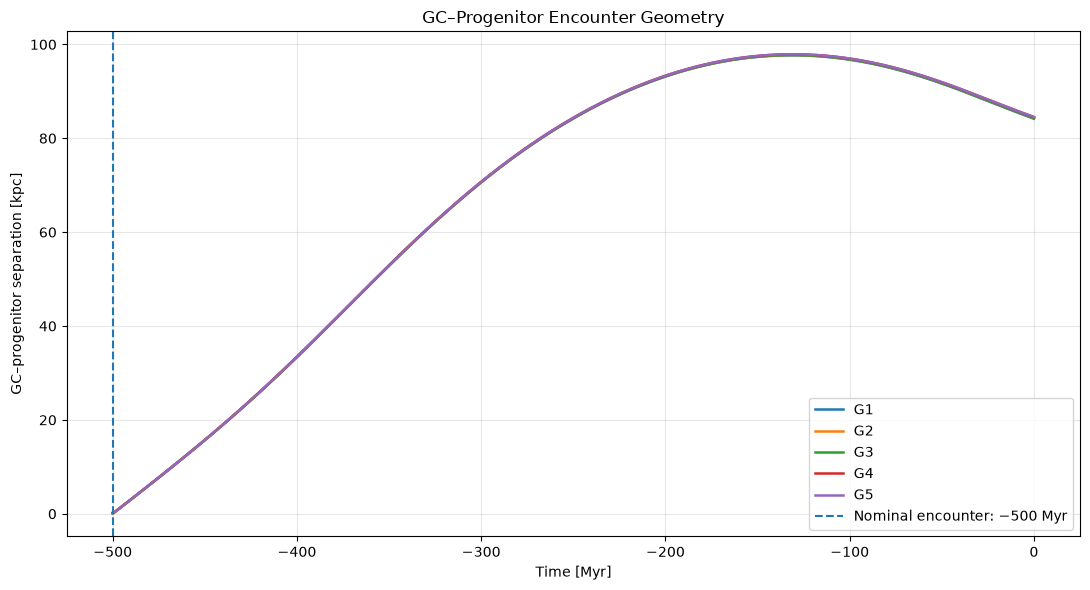

In [26]:
# ============================================================
# GC-PROGENITOR SEPARATION VS TIME
# ============================================================

print("\n" + "=" * 100)
print("GC-PROGENITOR SEPARATION VS TIME")
print("=" * 100)

fig, ax = plt.subplots(figsize=(11, 6))

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]
    result = GC_RECOVERY[case]

    time = result["time"]
    separation = result["separation"]

    ax.plot(
        time,
        separation,
        linewidth=1.8,
        label=case,
    )

ax.axvline(
    GC_T_ENCOUNTER.to_value(u.Myr),
    linestyle="--",
    linewidth=1.5,
    label="Nominal encounter: −500 Myr",
)

ax.set_xlabel("Time [Myr]")
ax.set_ylabel("GC–progenitor separation [kpc]")
ax.set_title("GC–Progenitor Encounter Geometry")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

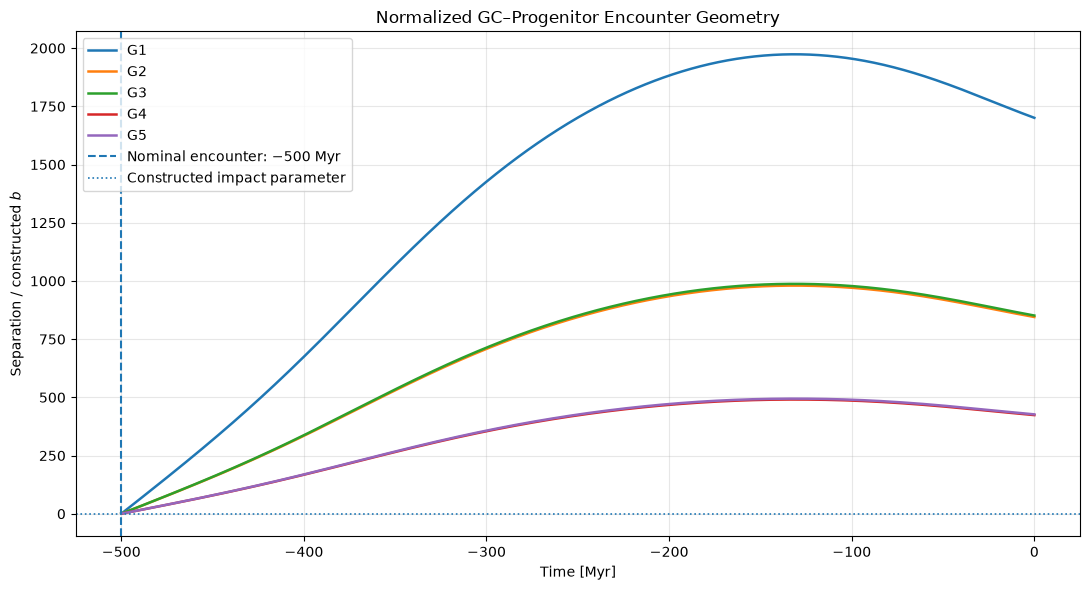

In [27]:
# ============================================================
# NORMALIZED GC-PROGENITOR SEPARATION
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    result = GC_RECOVERY[case]

    time = result["time"]
    separation = result["separation"]

    target_b = encounter["impact_parameter"].to_value(
        u.kpc
    )

    separation_ratio = separation / target_b

    ax.plot(
        time,
        separation_ratio,
        linewidth=1.8,
        label=case,
    )

ax.axvline(
    GC_T_ENCOUNTER.to_value(u.Myr),
    linestyle="--",
    linewidth=1.5,
    label="Nominal encounter: −500 Myr",
)

ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.2,
    label="Constructed impact parameter",
)

ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Separation / constructed $b$")
ax.set_title("Normalized GC–Progenitor Encounter Geometry")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


ZOOMED GC-PROGENITOR ENCOUNTER


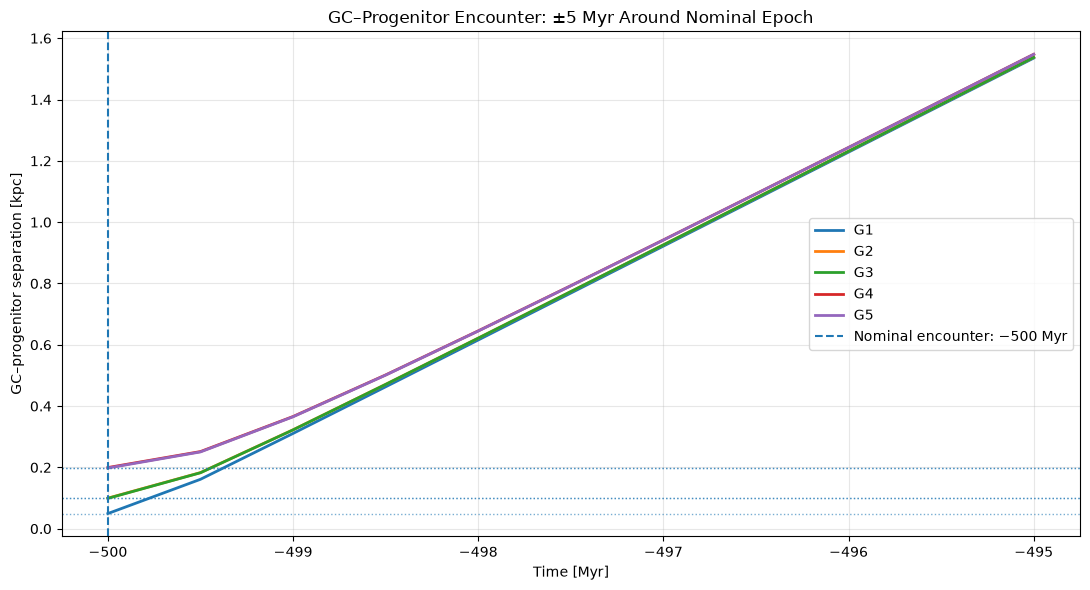

In [28]:
# ============================================================
# ZOOMED GC-PROGENITOR ENCOUNTER
# ============================================================

print("\n" + "=" * 100)
print("ZOOMED GC-PROGENITOR ENCOUNTER")
print("=" * 100)

fig, ax = plt.subplots(figsize=(11, 6))

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]
    result = GC_RECOVERY[case]

    time = result["time"]
    separation = result["separation"]

    mask = (
        (time >= -505.0) &
        (time <= -495.0)
    )

    ax.plot(
        time[mask],
        separation[mask],
        linewidth=2.0,
        label=case,
    )

    target_b = encounter["impact_parameter"].to_value(u.kpc)

    ax.axhline(
        target_b,
        linestyle=":",
        linewidth=1.0,
        alpha=0.6,
    )

ax.axvline(
    GC_T_ENCOUNTER.to_value(u.Myr),
    linestyle="--",
    linewidth=1.5,
    label="Nominal encounter: −500 Myr",
)

ax.set_xlabel("Time [Myr]")
ax.set_ylabel("GC–progenitor separation [kpc]")
ax.set_title("GC–Progenitor Encounter: ±5 Myr Around Nominal Epoch")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# FINAL GC ENCOUNTER GEOMETRY SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL GC ENCOUNTER GEOMETRY SUMMARY")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]
    result = GC_RECOVERY_FINE[case]

    # Convert ALL target quantities to plain numerical values
    # so that the comparison is unit-consistent.
    target_t = encounter["t_encounter"].to_value(u.Myr)
    target_b = encounter["impact_parameter"].to_value(u.kpc)
    target_v = encounter["relative_speed"].to_value(u.km / u.s)

    recovered_t = result["t_closest"]
    recovered_b = result["b_closest"]
    recovered_v = result["vrel_closest"]

    dt_error = recovered_t - target_t
    db_error = recovered_b - target_b
    dv_error = recovered_v - target_v

    print(f"\n{case}")
    print(f"  target time       = {target_t:10.3f} Myr")
    print(f"  recovered time    = {recovered_t:10.3f} Myr")
    print(f"  Δt                = {dt_error:+.3e} Myr")

    print(f"  target b          = {target_b:10.6f} kpc")
    print(f"  recovered b       = {recovered_b:10.6f} kpc")
    print(f"  Δb                = {db_error:+.3e} kpc")

    print(f"  target v_rel      = {target_v:10.6f} km/s")
    print(f"  recovered v_rel   = {recovered_v:10.6f} km/s")
    print(f"  Δv                = {dv_error:+.3e} km/s")

    # Fine recovery should be essentially exact at the
    # 0.05 Myr diagnostic timestep.
    assert abs(dt_error) <= FINE_DT.to_value(u.Myr)

    # Impact parameter and relative velocity should recover
    # the deliberately constructed encounter.
    assert abs(db_error) < 0.01
    assert abs(dv_error) < 5.0

print("\nFinal encounter geometry validation: PASS")


FINAL GC ENCOUNTER GEOMETRY SUMMARY

G1
  target time       =   -500.000 Myr
  recovered time    =   -500.000 Myr
  Δt                = +0.000e+00 Myr
  target b          =   0.049495 kpc
  recovered b       =   0.049611 kpc
  Δb                = +1.160e-04 kpc
  target v_rel      = 300.000000 km/s
  recovered v_rel   = 299.993345 km/s
  Δv                = -6.655e-03 km/s

G2
  target time       =   -500.000 Myr
  recovered time    =   -500.000 Myr
  Δt                = +0.000e+00 Myr
  target b          =   0.099749 kpc
  recovered b       =   0.099863 kpc
  Δb                = +1.141e-04 kpc
  target v_rel      = 300.000000 km/s
  recovered v_rel   = 299.993347 km/s
  Δv                = -6.653e-03 km/s

G3
  target time       =   -500.000 Myr
  recovered time    =   -500.000 Myr
  Δt                = +0.000e+00 Myr
  target b          =   0.098990 kpc
  recovered b       =   0.099104 kpc
  Δb                = +1.141e-04 kpc
  target v_rel      = 300.000000 km/s
  recovered v_rel  

In [30]:
# ============================================================
# GC FORWARD-BACKWARD ROUND-TRIP CONSISTENCY
# ============================================================

print("\n" + "=" * 100)
print("GC FORWARD-BACKWARD ROUND-TRIP CONSISTENCY")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    # Original constructed state at -500 Myr
    gc_initial = gd.PhaseSpacePosition(
        pos=encounter["position"] * u.kpc,
        vel=encounter["velocity"] * u.kpc / u.Myr,
    )

    # Stored forward-integrated orbit
    gc_forward = GC_PRESENT_STATES[case]["orbit"]

    # Present-day state
    gc_present = gc_forward[-1]

    # Integrate that present-day state backward
    gc_return = mw.integrate_orbit(
        gc_present,
        dt=-DT,
        t1=0 * u.Myr,
        t2=GC_T_ENCOUNTER,
    )

    gc_recovered = gc_return[-1]

    # Position error
    delta_r = (
        gc_recovered.pos.xyz
        - gc_initial.pos.xyz
    )

    position_error = np.linalg.norm(
        delta_r.to_value(u.kpc)
    )

    # Velocity error
    delta_v = (
        gc_recovered.vel.d_xyz
        - gc_initial.vel.d_xyz
    )

    velocity_error = (
        np.linalg.norm(
            delta_v.to_value(u.kpc / u.Myr)
        )
        * u.kpc / u.Myr
    ).to_value(u.km / u.s)

    print(f"\n{case}:")
    print(
        f"  position round-trip error = "
        f"{position_error:.9e} kpc"
    )
    print(
        f"  velocity round-trip error = "
        f"{velocity_error:.9e} km/s"
    )

    assert np.isfinite(position_error)
    assert np.isfinite(velocity_error)

print("\nGC forward-backward round-trip diagnostic: PASS")


GC FORWARD-BACKWARD ROUND-TRIP CONSISTENCY

G1:
  position round-trip error = 4.550560269e-15 kpc
  velocity round-trip error = 2.713918595e-14 km/s

G2:
  position round-trip error = 1.398704774e-14 kpc
  velocity round-trip error = 1.094015561e-13 km/s

G3:
  position round-trip error = 2.919189944e-14 kpc
  velocity round-trip error = 1.628351157e-13 km/s

G4:
  position round-trip error = 3.972054645e-15 kpc
  velocity round-trip error = 6.919161936e-14 km/s

G5:
  position round-trip error = 8.188600426e-15 kpc
  velocity round-trip error = 1.159386532e-13 km/s

GC forward-backward round-trip diagnostic: PASS


In [31]:
# ============================================================
# DIAGNOSE GC FORWARD/BACKWARD TIME GRIDS
# ============================================================

print("\n" + "=" * 100)
print("GC FORWARD/BACKWARD TIME-GRID DIAGNOSTIC")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    gc_forward = GC_PRESENT_STATES[case]["orbit"]

    # Forward orbit endpoints
    t_forward = gc_forward.t.to_value(u.Myr)

    gc_initial = gd.PhaseSpacePosition(
        pos=encounter["position"] * u.kpc,
        vel=encounter["velocity"] * u.kpc / u.Myr,
    )

    # State actually returned at the start/end of forward orbit
    forward_start = gc_forward[0]
    forward_end = gc_forward[-1]

    # Backward integration from the actual forward endpoint
    gc_backward = mw.integrate_orbit(
        forward_end,
        dt=-DT,
        t1=t_forward[-1] * u.Myr,
        t2=t_forward[0] * u.Myr,
    )

    t_backward = gc_backward.t.to_value(u.Myr)

    backward_end = gc_backward[-1]

    # Compare recovered state with original constructed state
    pos_error = np.linalg.norm(
        (
            backward_end.pos.xyz
            - gc_initial.pos.xyz
        ).to_value(u.kpc)
    )

    vel_error = (
        np.linalg.norm(
            (
                backward_end.vel.d_xyz
                - gc_initial.vel.d_xyz
            ).to_value(u.kpc / u.Myr)
        )
        * u.kpc / u.Myr
    ).to_value(u.km / u.s)

    print(f"\n{case}")

    print(
        f"  forward time range : "
        f"{t_forward[0]:.6f} → {t_forward[-1]:.6f} Myr"
    )

    print(
        f"  backward time range: "
        f"{t_backward[0]:.6f} → {t_backward[-1]:.6f} Myr"
    )

    print(
        f"  forward start time error from -500 Myr = "
        f"{t_forward[0] - (-500.0):.6e} Myr"
    )

    print(
        f"  forward end time error from 0 Myr = "
        f"{t_forward[-1] - 0.0:.6e} Myr"
    )

    print(
        f"  backward final time error from -500 Myr = "
        f"{t_backward[-1] - (-500.0):.6e} Myr"
    )

    print(
        f"  round-trip position error = "
        f"{pos_error:.9e} kpc"
    )

    print(
        f"  round-trip velocity error = "
        f"{vel_error:.9e} km/s"
    )

print("\nTime-grid diagnostic complete.")


GC FORWARD/BACKWARD TIME-GRID DIAGNOSTIC

G1
  forward time range : -500.000000 → 0.000000 Myr
  backward time range: 0.000000 → -500.000000 Myr
  forward start time error from -500 Myr = 0.000000e+00 Myr
  forward end time error from 0 Myr = 0.000000e+00 Myr
  backward final time error from -500 Myr = 0.000000e+00 Myr
  round-trip position error = 4.550560269e-15 kpc
  round-trip velocity error = 2.713918595e-14 km/s

G2
  forward time range : -500.000000 → 0.000000 Myr
  backward time range: 0.000000 → -500.000000 Myr
  forward start time error from -500 Myr = 0.000000e+00 Myr
  forward end time error from 0 Myr = 0.000000e+00 Myr
  backward final time error from -500 Myr = 0.000000e+00 Myr
  round-trip position error = 1.398704774e-14 kpc
  round-trip velocity error = 1.094015561e-13 km/s

G3
  forward time range : -500.000000 → 0.000000 Myr
  backward time range: 0.000000 → -500.000000 Myr
  forward start time error from -500 Myr = 0.000000e+00 Myr
  forward end time error from 0 

In [32]:
# ============================================================
# Small unperturbed control stream
# ============================================================

CONTROL_RNG = ConstrainedChenRandomState(RNG_SEED)

CONTROL_DF = gd.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=CONTROL_RNG,
)

CONTROL_GENERATOR = gd.MockStreamGenerator(
    df=CONTROL_DF,
    hamiltonian=MW_HAMILTONIAN,
    progenitor_potential=PROGENITOR_POTENTIAL,
)

CONTROL_STREAM, CONTROL_PROG_ORBIT = CONTROL_GENERATOR.run(
    w_prog,
    prog_mass=M_PROG,
    t1=0 * u.Myr,
    t2=-SMOKE_T_STRIP,
    dt=-SMOKE_DT,
    release_every=1,
    n_particles=SMOKE_N_PARTICLES,
    Integrator="leapfrog",
)

CONTROL_XYZ = CONTROL_STREAM.xyz.to_value(u.kpc)

print("Control stream:")
print("  shape =", CONTROL_XYZ.shape)
print("  finite =", np.isfinite(CONTROL_XYZ).all())
print("  rejected q<=0 =", CONTROL_RNG.rejected_q_nonpositive)

assert CONTROL_XYZ.shape[0] == 3
assert np.isfinite(CONTROL_XYZ).all()

print("\nUnperturbed control stream: PASS")

Control stream:
  shape = (3, 76864)
  finite = True
  rejected q<=0 = 1

Unperturbed control stream: PASS


In [33]:
# ============================================================
# GC perturbation vs control
# ============================================================

GC_PERTURBATION_DIAGNOSTICS = {}

print("=" * 100)
print("GC PERTURBATION VS CONTROL")
print("=" * 100)

for case in GC_ENCOUNTERS:

    case_name = case["case"]

    gc_stream = GC_HISTORY_SMOKE[case_name]["stream"]   

    gc_xyz = gc_stream.xyz.to_value(u.kpc)

    # --------------------------------------------------------
    # Check that the particle count matches the control
    # --------------------------------------------------------

    assert gc_xyz.shape == CONTROL_XYZ.shape

    # --------------------------------------------------------
    # Particle-by-particle spatial displacement
    # --------------------------------------------------------

    delta_xyz = gc_xyz - CONTROL_XYZ

    displacement = np.linalg.norm(
        delta_xyz,
        axis=0,
    )

    max_displacement = np.max(
        displacement
    )

    rms_displacement = np.sqrt(
        np.mean(displacement**2)
    )

    median_displacement = np.median(
        displacement
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    GC_PERTURBATION_DIAGNOSTICS[case_name] = {
        "max_displacement": max_displacement,
        "rms_displacement": rms_displacement,
        "median_displacement": median_displacement,
    }

    print(f"\n{case_name}:")
    print(
        f"  max Δx    = "
        f"{max_displacement:.6e} kpc"
    )
    print(
        f"  RMS Δx    = "
        f"{rms_displacement:.6e} kpc"
    )
    print(
        f"  median Δx = "
        f"{median_displacement:.6e} kpc"
    )

    assert np.isfinite(
        displacement
    ).all()

print("\nGC perturbation diagnostics: PASS")

GC PERTURBATION VS CONTROL

G1:
  max Δx    = 1.863469e+00 kpc
  RMS Δx    = 1.716249e-01 kpc
  median Δx = 4.541021e-02 kpc

G2:
  max Δx    = 1.516695e+00 kpc
  RMS Δx    = 1.873987e-01 kpc
  median Δx = 5.109733e-02 kpc

G3:
  max Δx    = 1.320425e+00 kpc
  RMS Δx    = 1.876138e-01 kpc
  median Δx = 5.114434e-02 kpc

G4:
  max Δx    = 1.353714e+00 kpc
  RMS Δx    = 1.514329e-01 kpc
  median Δx = 4.366995e-02 kpc

G5:
  max Δx    = 1.350189e+00 kpc
  RMS Δx    = 1.522533e-01 kpc
  median Δx = 4.382571e-02 kpc

GC perturbation diagnostics: PASS


In [34]:
# ============================================================
# GC PERTURBATION VS RELEASE TIME
# ============================================================

import numpy as np

print("\n" + "=" * 100)
print("GC PERTURBATION VS RELEASE TIME")
print("=" * 100)

GC_RELEASE_HISTORY = {}

for case in GC_ENCOUNTERS:

    case_name = case["case"]

    gc_stream = GC_HISTORY_SMOKE[case_name]["stream"]

    # Position arrays
    gc_pos = np.asarray(gc_stream.pos.xyz.to_value(u.kpc))
    ctrl_pos = np.asarray(CONTROL_STREAM.pos.xyz.to_value(u.kpc))

    # Particle-wise spatial displacement
    delta_x = np.linalg.norm(gc_pos - ctrl_pos, axis=0)

    # Release times
    release_time = np.asarray(
        gc_stream.release_time.to_value(u.Myr)
    )

    unique_times = np.unique(release_time)

    rows = []

    for t_release in unique_times:

        mask = np.isclose(release_time, t_release)

        dx = delta_x[mask]

        rows.append({
            "release_time_myr": t_release,
            "n_particles": dx.size,
            "median_dx_kpc": np.median(dx),
            "rms_dx_kpc": np.sqrt(np.mean(dx**2)),
            "max_dx_kpc": np.max(dx),
        })

    GC_RELEASE_HISTORY[case_name] = rows

    print(f"\n{case_name}:")
    print(f"  release epochs = {len(rows)}")
    print(
        f"  release range  = "
        f"{unique_times.min():.3f} to {unique_times.max():.3f} Myr"
    )

    # Show the epochs with the largest RMS response
    ranked = sorted(
        rows,
        key=lambda x: x["rms_dx_kpc"],
        reverse=True,
    )

    print("  largest RMS responses:")

    for row in ranked[:10]:
        print(
            f"    t = {row['release_time_myr']:8.3f} Myr | "
            f"N = {row['n_particles']:4d} | "
            f"median = {row['median_dx_kpc']:.6e} kpc | "
            f"RMS = {row['rms_dx_kpc']:.6e} kpc | "
            f"max = {row['max_dx_kpc']:.6e} kpc"
        )

print("\nGC release-time diagnostics: PASS")


GC PERTURBATION VS RELEASE TIME

G1:
  release epochs = 1201
  release range  = -600.000 to 0.000 Myr
  largest RMS responses:
    t = -340.000 Myr | N =   64 | median = 1.107630e-01 kpc | RMS = 4.811180e-01 kpc | max = 1.125163e+00 kpc
    t = -339.000 Myr | N =   64 | median = 9.848979e-02 kpc | RMS = 4.751905e-01 kpc | max = 1.113894e+00 kpc
    t = -349.500 Myr | N =   64 | median = 1.555565e-01 kpc | RMS = 4.706060e-01 kpc | max = 1.206224e+00 kpc
    t = -348.000 Myr | N =   64 | median = 9.689761e-02 kpc | RMS = 4.684357e-01 kpc | max = 1.132911e+00 kpc
    t = -344.000 Myr | N =   64 | median = 1.109644e-01 kpc | RMS = 4.673398e-01 kpc | max = 1.203495e+00 kpc
    t = -358.000 Myr | N =   64 | median = 1.115884e-01 kpc | RMS = 4.643489e-01 kpc | max = 1.272558e+00 kpc
    t = -346.500 Myr | N =   64 | median = 1.177639e-01 kpc | RMS = 4.470918e-01 kpc | max = 1.111706e+00 kpc
    t = -350.500 Myr | N =   64 | median = 9.726002e-02 kpc | RMS = 4.452915e-01 kpc | max = 1.217945e

In [35]:
# ============================================================
# GC PERTURBATION: RELEASE-TIME BINS AROUND ENCOUNTER
# ============================================================

print("\n" + "=" * 100)
print("GC PERTURBATION: RELEASE-TIME BINS AROUND ENCOUNTER")
print("=" * 100)

GC_RELEASE_BINS = [
    (-600, -550),
    (-550, -525),
    (-525, -510),
    (-510, -500),
    (-500, -490),
    (-490, -475),
    (-475, -450),
    (-450, -400),
    (-400, -350),
    (-350, -300),
    (-300, -200),
    (-200, -100),
    (-100, 0),
]

GC_RELEASE_BIN_RESULTS = {}

for encounter in GC_ENCOUNTERS:

    case_name = encounter["case"]

    gc_stream = GC_HISTORY_SMOKE[case_name]["stream"]

    gc_xyz = gc_stream.xyz.to_value(u.kpc)
    ctrl_xyz = CONTROL_STREAM.xyz.to_value(u.kpc)

    displacement = np.linalg.norm(
        gc_xyz - ctrl_xyz,
        axis=0,
    )

    release_time = gc_stream.release_time.to_value(u.Myr)

    results = []

    print(f"\n{case_name}:")

    for t_lo, t_hi in GC_RELEASE_BINS:

        mask = (
            (release_time >= t_lo)
            & (release_time < t_hi)
        )

        dx = displacement[mask]

        if dx.size == 0:
            continue

        result = {
            "t_lo": t_lo,
            "t_hi": t_hi,
            "n_particles": dx.size,
            "median_dx": np.median(dx),
            "rms_dx": np.sqrt(np.mean(dx**2)),
            "max_dx": np.max(dx),
        }

        results.append(result)

        print(
            f"  {t_lo:7.1f} to {t_hi:7.1f} Myr | "
            f"N = {dx.size:5d} | "
            f"median = {result['median_dx']:.5e} kpc | "
            f"RMS = {result['rms_dx']:.5e} kpc | "
            f"max = {result['max_dx']:.5e} kpc"
        )

    GC_RELEASE_BIN_RESULTS[case_name] = results

print("\nGC release-time bin diagnostic: PASS")


GC PERTURBATION: RELEASE-TIME BINS AROUND ENCOUNTER

G1:
   -600.0 to  -550.0 Myr | N =  6400 | median = 8.03891e-02 kpc | RMS = 7.61791e-02 kpc | max = 5.61275e-01 kpc
   -550.0 to  -525.0 Myr | N =  3200 | median = 7.92084e-02 kpc | RMS = 7.84139e-02 kpc | max = 8.12563e-01 kpc
   -525.0 to  -510.0 Myr | N =  1920 | median = 8.13843e-02 kpc | RMS = 9.62245e-02 kpc | max = 1.86347e+00 kpc
   -510.0 to  -500.0 Myr | N =  1280 | median = 7.33149e-02 kpc | RMS = 8.25195e-02 kpc | max = 5.31346e-01 kpc
   -500.0 to  -490.0 Myr | N =  1280 | median = 2.14425e-02 kpc | RMS = 6.01242e-02 kpc | max = 9.98172e-01 kpc
   -490.0 to  -475.0 Myr | N =  1920 | median = 2.71234e-02 kpc | RMS = 6.08567e-02 kpc | max = 1.00889e+00 kpc
   -475.0 to  -450.0 Myr | N =  3200 | median = 4.17913e-02 kpc | RMS = 7.60887e-02 kpc | max = 1.04331e+00 kpc
   -450.0 to  -400.0 Myr | N =  6400 | median = 8.60686e-02 kpc | RMS = 1.29981e-01 kpc | max = 9.56173e-01 kpc
   -400.0 to  -350.0 Myr | N =  6400 | median 

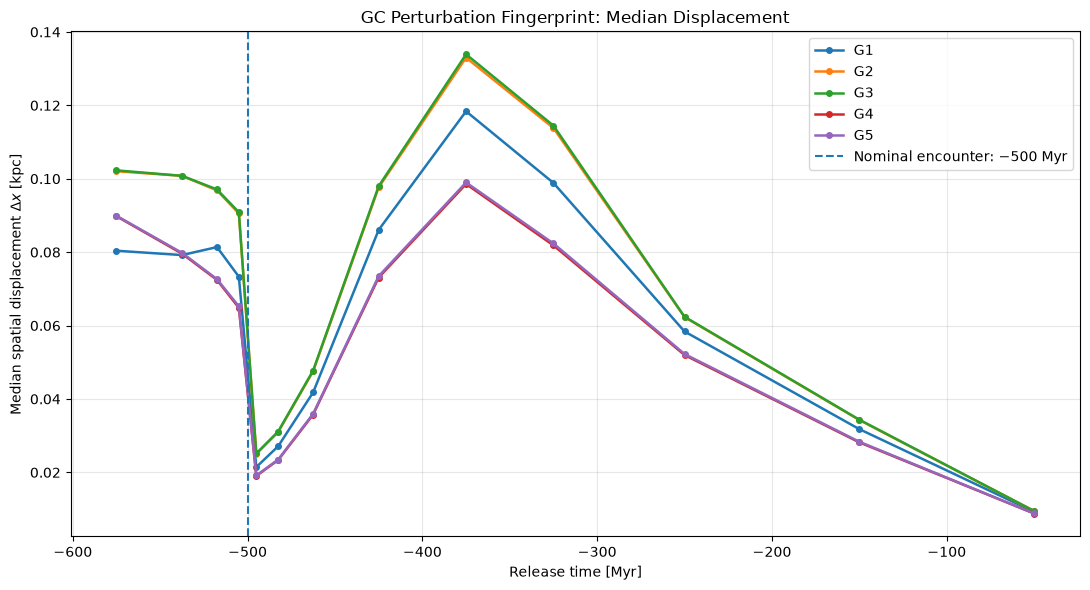

In [36]:
# ============================================================
# GC PERTURBATION FINGERPRINT VS RELEASE TIME
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for case_name, results in GC_RELEASE_BIN_RESULTS.items():

    # Use bin centers for plotting
    t_center = np.array([
        0.5 * (row["t_lo"] + row["t_hi"])
        for row in results
    ])

    median_dx = np.array([
        row["median_dx"]
        for row in results
    ])

    ax.plot(
        t_center,
        median_dx,
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=case_name,
    )

ax.axvline(
    -500,
    linestyle="--",
    linewidth=1.5,
    label="Nominal encounter: −500 Myr",
)

ax.set_xlabel("Release time [Myr]")
ax.set_ylabel(r"Median spatial displacement $\Delta x$ [kpc]")
ax.set_title("GC Perturbation Fingerprint: Median Displacement")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

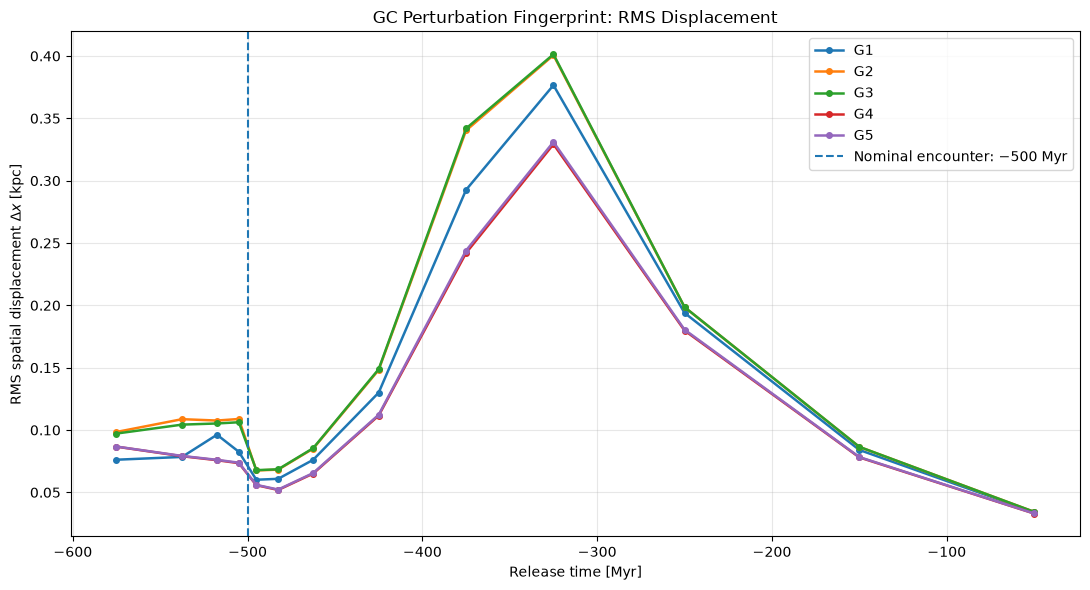

In [37]:
# ============================================================
# RMS PERTURBATION FINGERPRINT
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for case_name, results in GC_RELEASE_BIN_RESULTS.items():

    t_center = np.array([
        0.5 * (row["t_lo"] + row["t_hi"])
        for row in results
    ])

    rms_dx = np.array([
        row["rms_dx"]
        for row in results
    ])

    ax.plot(
        t_center,
        rms_dx,
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=case_name,
    )

ax.axvline(
    -500,
    linestyle="--",
    linewidth=1.5,
    label="Nominal encounter: −500 Myr",
)

ax.set_xlabel("Release time [Myr]")
ax.set_ylabel(r"RMS spatial displacement $\Delta x$ [kpc]")
ax.set_title("GC Perturbation Fingerprint: RMS Displacement")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# GC PRODUCTION CONFIGURATION
# ============================================================

PROD_T_STRIP = T_STRIP
PROD_DT = DT
PROD_RELEASE_CADENCE = RELEASE_CADENCE
PROD_N_PARTICLES = N_PARTICLES

print("=" * 100)
print("GC PRODUCTION CONFIGURATION")
print("=" * 100)

print(f"T_strip          = {PROD_T_STRIP}")
print(f"dt               = {PROD_DT}")
print(f"release cadence  = {PROD_RELEASE_CADENCE}")
print(f"particles        = {PROD_N_PARTICLES}")

# Number of release epochs
n_release_epochs = int(
    round(
        PROD_T_STRIP.to_value(u.Myr)
        / PROD_RELEASE_CADENCE.to_value(u.Myr)
    )
) + 1

particles_per_epoch = 2 * 32

expected_particles = (
    n_release_epochs * particles_per_epoch
)

print(f"release epochs   = {n_release_epochs}")
print(f"particles/epoch  = {particles_per_epoch}")
print(f"expected total   = {expected_particles}")

assert expected_particles == PROD_N_PARTICLES

print("\nProduction configuration: PASS")

GC PRODUCTION CONFIGURATION
T_strip          = 1500.0 Myr
dt               = 0.5 Myr
release cadence  = 0.5 Myr
particles        = 192064
release epochs   = 3001
particles/epoch  = 64
expected total   = 192064

Production configuration: PASS


In [39]:
# ============================================================
# GC PRODUCTION STREAM GENERATION
# ============================================================

GC_PRODUCTION_STREAMS = {}
GC_PRODUCTION_PROG_ORBITS = {}

print("\n" + "=" * 100)
print("GC PRODUCTION STREAM GENERATION")
print("=" * 100)

for encounter in GC_ENCOUNTERS:

    case = encounter["case"]

    generator = GC_GENERATORS[case]["generator"]
    rng = GC_GENERATORS[case]["rng"]
    gc_nbody = GC_NBODIES[case]["nbody"]

    # --------------------------------------------------------
    # Reset constrained RNG
    # --------------------------------------------------------

    rng.seed(RNG_SEED)
    rng.rejected_q_nonpositive = 0

    print(f"\n{'-' * 80}")
    print(f"Running {case}")
    print(f"{'-' * 80}")

    # --------------------------------------------------------
    # Full production stream
    # --------------------------------------------------------

    stream, prog_orbit = generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=gc_nbody,
        t1=0 * u.Myr,
        t2=-PROD_T_STRIP,
        dt=-PROD_DT,
        release_every=1,
        n_particles=32,
        Integrator="leapfrog",
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    GC_PRODUCTION_STREAMS[case] = stream
    GC_PRODUCTION_PROG_ORBITS[case] = prog_orbit

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    pos = stream.pos.xyz.to_value(u.kpc)
    vel = stream.vel.d_xyz.to_value(u.kpc / u.Myr)
    release_time = stream.release_time.to_value(u.Myr)

    finite_pos = np.isfinite(pos).all()
    finite_vel = np.isfinite(vel).all()

    print(f"particles         = {stream.shape[0]}")
    print(f"finite positions  = {finite_pos}")
    print(f"finite velocities = {finite_vel}")
    print(
        f"release range     = "
        f"{release_time.min():.3f} to "
        f"{release_time.max():.3f} Myr"
    )
    print(
        f"rejected q<=0     = "
        f"{rng.rejected_q_nonpositive}"
    )

    assert stream.shape[0] == PROD_N_PARTICLES
    assert finite_pos
    assert finite_vel

print("\nGC production stream generation: PASS")


GC PRODUCTION STREAM GENERATION

--------------------------------------------------------------------------------
Running G1
--------------------------------------------------------------------------------
particles         = 192064
finite positions  = True
finite velocities = True
release range     = -1500.000 to 0.000 Myr
rejected q<=0     = 2

--------------------------------------------------------------------------------
Running G2
--------------------------------------------------------------------------------
particles         = 192064
finite positions  = True
finite velocities = True
release range     = -1500.000 to 0.000 Myr
rejected q<=0     = 2

--------------------------------------------------------------------------------
Running G3
--------------------------------------------------------------------------------
particles         = 192064
finite positions  = True
finite velocities = True
release range     = -1500.000 to 0.000 Myr
rejected q<=0     = 2

------------------

In [40]:
# ============================================================
# VALIDATE GC PRODUCTION STREAMS
# ============================================================

print("\n" + "=" * 100)
print("VALIDATE GC PRODUCTION STREAMS")
print("=" * 100)

for case, stream in GC_PRODUCTION_STREAMS.items():

    pos = stream.pos.xyz.to_value(u.kpc)
    vel = stream.vel.d_xyz.to_value(u.kpc / u.Myr)
    release_time = stream.release_time.to_value(u.Myr)

    print(f"\n{case}:")
    print(f"  shape             = {stream.shape}")
    print(f"  finite positions  = {np.isfinite(pos).all()}")
    print(f"  finite velocities = {np.isfinite(vel).all()}")
    print(
        f"  release range     = "
        f"{release_time.min():.3f} "
        f"to {release_time.max():.3f} Myr"
    )

    assert stream.shape[0] == PROD_N_PARTICLES
    assert np.isfinite(pos).all()
    assert np.isfinite(vel).all()

    assert np.isclose(
        release_time.min(),
        -PROD_T_STRIP.to_value(u.Myr),
    )

    assert np.isclose(
        release_time.max(),
        0.0,
    )

print("\nProduction stream validation: PASS")


VALIDATE GC PRODUCTION STREAMS

G1:
  shape             = (192064,)
  finite positions  = True
  finite velocities = True
  release range     = -1500.000 to 0.000 Myr

G2:
  shape             = (192064,)
  finite positions  = True
  finite velocities = True
  release range     = -1500.000 to 0.000 Myr

G3:
  shape             = (192064,)
  finite positions  = True
  finite velocities = True
  release range     = -1500.000 to 0.000 Myr

G4:
  shape             = (192064,)
  finite positions  = True
  finite velocities = True
  release range     = -1500.000 to 0.000 Myr

G5:
  shape             = (192064,)
  finite positions  = True
  finite velocities = True
  release range     = -1500.000 to 0.000 Myr

Production stream validation: PASS


In [41]:
# ============================================================
# M1.5 — Reconstruct constrained Chen stream generator
# ============================================================

class ConstrainedChenRandomState(np.random.RandomState):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_rejected = 0

    def multivariate_normal(
        self,
        mean,
        cov=1,
        size=None,
        check_valid="warn",
        tol=1e-8,
    ):
        if size is not None:
            return super().multivariate_normal(
                mean,
                cov,
                size=size,
                check_valid=check_valid,
                tol=tol,
            )

        while True:
            draw = super().multivariate_normal(
                mean,
                cov,
                check_valid=check_valid,
                tol=tol,
            )

            draw = np.asarray(draw)

            if draw[0] > 0:
                return draw

            self.n_rejected += 1


def make_stream_generator(seed):
    rng = ConstrainedChenRandomState(seed)

    df = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=rng,
    )

    generator = ms.MockStreamGenerator(
        df=df,
        hamiltonian=MW_HAMILTONIAN,
        progenitor_potential=PROGENITOR_POTENTIAL,
    )

    generator._constrained_rng = rng

    return generator


print("Constrained Chen generator helper: PASS")

Constrained Chen generator helper: PASS


In [43]:
# ============================================================
# GC PRODUCTION CONTROL STREAM
# ============================================================
#
# Generate the matched unperturbed control stream using the
# exact same production configuration as the GC perturbation
# runs, but without the GC perturber.
# ============================================================

CONTROL_PROD_RNG = ConstrainedChenRandomState(RNG_SEED)

CONTROL_PROD_DF = gd.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=CONTROL_PROD_RNG,
)

CONTROL_PROD_GENERATOR = gd.MockStreamGenerator(
    df=CONTROL_PROD_DF,
    hamiltonian=MW_HAMILTONIAN,
    progenitor_potential=PROGENITOR_POTENTIAL,
)

CONTROL_PRODUCTION_STREAM, CONTROL_PRODUCTION_PROG_ORBIT = (
    CONTROL_PROD_GENERATOR.run(
        w_prog,
        prog_mass=M_PROG,
        t1=0 * u.Myr,
        t2=-PROD_T_STRIP,
        dt=-PROD_DT,
        release_every=1,
        n_particles=32,
        Integrator="leapfrog",
    )
)

# Extract arrays for validation
CONTROL_PROD_POS = CONTROL_PRODUCTION_STREAM.xyz.to_value(u.kpc)
CONTROL_PROD_VEL = CONTROL_PRODUCTION_STREAM.v_xyz.to_value(u.km / u.s)
CONTROL_PROD_T = CONTROL_PRODUCTION_STREAM.release_time.to_value(u.Myr)

N_CONTROL_PROD = CONTROL_PROD_POS.shape[1]

print("=" * 70)
print("GC PRODUCTION CONTROL STREAM")
print("=" * 70)

print(f"Particles       : {N_CONTROL_PROD}")
print(
    f"Release range   : "
    f"{CONTROL_PROD_T.min():.3f} → "
    f"{CONTROL_PROD_T.max():.3f} Myr"
)

print(
    "Finite positions:",
    np.all(np.isfinite(CONTROL_PROD_POS))
)

print(
    "Finite velocities:",
    np.all(np.isfinite(CONTROL_PROD_VEL))
)

print("=" * 70)

GC PRODUCTION CONTROL STREAM
Particles       : 192064
Release range   : -1500.000 → 0.000 Myr
Finite positions: True
Finite velocities: True


In [46]:
# ============================================================
# VALIDATE GC PRODUCTION CONTROL
# ============================================================

expected_particles = 192_064

assert N_CONTROL_PROD == expected_particles
assert CONTROL_PROD_POS.shape == (3, expected_particles)
assert CONTROL_PROD_VEL.shape == (3, expected_particles)

assert np.all(np.isfinite(CONTROL_PROD_POS))
assert np.all(np.isfinite(CONTROL_PROD_VEL))

assert np.isclose(
    CONTROL_PROD_T.min(),
    -PROD_T_STRIP.to_value(u.Myr)
)

assert np.isclose(
    CONTROL_PROD_T.max(),
    0.0
)

print("=" * 70)
print("GC PRODUCTION CONTROL VALIDATION")
print("=" * 70)

print(f"Particle count    : {N_CONTROL_PROD}")
print(f"Expected          : {expected_particles}")
print(f"Position shape    : {CONTROL_PROD_POS.shape}")
print(f"Velocity shape    : {CONTROL_PROD_VEL.shape}")
print(
    f"Release range     : "
    f"{CONTROL_PROD_T.min():.3f} → "
    f"{CONTROL_PROD_T.max():.3f} Myr"
)
print(f"Finite positions  : {np.all(np.isfinite(CONTROL_PROD_POS))}")
print(f"Finite velocities : {np.all(np.isfinite(CONTROL_PROD_VEL))}")

print("=" * 70)
print("Production control stream validation: PASS")
print("=" * 70)

GC PRODUCTION CONTROL VALIDATION
Particle count    : 192064
Expected          : 192064
Position shape    : (3, 192064)
Velocity shape    : (3, 192064)
Release range     : -1500.000 → 0.000 Myr
Finite positions  : True
Finite velocities : True
Production control stream validation: PASS


In [50]:
# ============================================================
# GC OBSERVABLE TRANSFORMATION
# ============================================================
#
# Convert a Gala MockStream into the common six-dimensional
# GD-1 observable representation used by the DM/GMC analyses.
# ============================================================

def mockstream_to_gd1(stream):

    # MockStream -> ICRS
    icrs = stream.to_coord_frame(ICRS())

    # ICRS -> GD-1 stream coordinates
    gd1 = icrs.transform_to(gd1_frame)

    return {
        "phi1_deg": gd1.phi1.to_value(u.deg),
        "phi2_deg": gd1.phi2.to_value(u.deg),
        "distance_kpc": gd1.distance.to_value(u.kpc),
        "pm1_masyr": gd1.pm_phi1_cosphi2.to_value(u.mas / u.yr),
        "pm2_masyr": gd1.pm_phi2.to_value(u.mas / u.yr),
        "rv_kms": gd1.radial_velocity.to_value(u.km / u.s),

        # Preserve the particle-level metadata
        "release_time_myr": (
            stream.release_time.to_value(u.Myr)
        ),
        "lead_trail": np.asarray(stream.lead_trail),
    }

print("=" * 70)
print("GC OBSERVABLE TRANSFORMATION")
print("=" * 70)

print("Function: mockstream_to_gd1")
print("Coordinate path:")
print("  MockStream → ICRS → GD1Koposov10")

print("\nObservables:")
print("  phi1_deg")
print("  phi2_deg")
print("  distance_kpc")
print("  pm1_masyr")
print("  pm2_masyr")
print("  rv_kms")
print("  release_time_myr")
print("  lead_trail")

print("=" * 70)
print("Observable transformation helper: READY")
print("=" * 70)

GC OBSERVABLE TRANSFORMATION
Function: mockstream_to_gd1
Coordinate path:
  MockStream → ICRS → GD1Koposov10

Observables:
  phi1_deg
  phi2_deg
  distance_kpc
  pm1_masyr
  pm2_masyr
  rv_kms
  release_time_myr
  lead_trail
Observable transformation helper: READY


In [51]:
# ============================================================
# GC PRODUCTION OBSERVABLE CONSTRUCTION
# ============================================================
#
# Transform the production GC streams and matched control into
# the common GD-1 observable representation used by the DM/GMC
# analysis.
#
# Observables:
#   phi1_deg
#   phi2_deg
#   distance_kpc
#   pm1_masyr
#   pm2_masyr
#   rv_kms
#   release_time_myr
# ============================================================

GC_PRODUCTION_OBSERVABLES = {}

for case in GC_PRODUCTION_STREAMS:

    stream = GC_PRODUCTION_STREAMS[case]

    GC_PRODUCTION_OBSERVABLES[case] = mockstream_to_gd1(stream)

# Matched production control
CONTROL_PRODUCTION_OBSERVABLES = mockstream_to_gd1(
    CONTROL_PRODUCTION_STREAM
)

print("=" * 70)
print("GC PRODUCTION OBSERVABLE CONSTRUCTION")
print("=" * 70)

for case in GC_PRODUCTION_OBSERVABLES:

    obs = GC_PRODUCTION_OBSERVABLES[case]

    print(f"\n{case}:")

    for key in [
        "phi1_deg",
        "phi2_deg",
        "distance_kpc",
        "pm1_masyr",
        "pm2_masyr",
        "rv_kms",
    ]:

        arr = np.asarray(obs[key])

        print(
            f"  {key:16s}: "
            f"N={arr.size:6d}, "
            f"finite={np.isfinite(arr).all()}"
        )

print("\nS_control:")

for key in [
    "phi1_deg",
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]:

    arr = np.asarray(CONTROL_PRODUCTION_OBSERVABLES[key])

    print(
        f"  {key:16s}: "
        f"N={arr.size:6d}, "
        f"finite={np.isfinite(arr).all()}"
    )

print("=" * 70)

GC PRODUCTION OBSERVABLE CONSTRUCTION

G1:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

G2:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

G3:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

G4:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       

In [52]:
# ============================================================
# VALIDATE GC PRODUCTION OBSERVABLES
# ============================================================

OBSERVABLE_KEYS = [
    "phi1_deg",
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]

EXPECTED_PROD_N = 192_064

# ------------------------------------------------------------
# Validate control
# ------------------------------------------------------------

for key in OBSERVABLE_KEYS:

    arr = np.asarray(
        CONTROL_PRODUCTION_OBSERVABLES[key]
    )

    assert arr.size == EXPECTED_PROD_N
    assert np.isfinite(arr).all()

# ------------------------------------------------------------
# Validate every GC case
# ------------------------------------------------------------

for case, obs in GC_PRODUCTION_OBSERVABLES.items():

    for key in OBSERVABLE_KEYS:

        arr = np.asarray(obs[key])

        assert arr.size == EXPECTED_PROD_N
        assert np.isfinite(arr).all()

# ------------------------------------------------------------
# Science-region definition
# ------------------------------------------------------------

SCIENCE_LO = -60.0
SCIENCE_HI = 0.0

print("=" * 70)
print("GC PRODUCTION OBSERVABLE VALIDATION")
print("=" * 70)

print(f"Expected particles : {EXPECTED_PROD_N}")
print(f"Science region     : {SCIENCE_LO} <= phi1 <= {SCIENCE_HI} deg")

print("\nControl:")

for key in OBSERVABLE_KEYS:

    arr = np.asarray(
        CONTROL_PRODUCTION_OBSERVABLES[key]
    )

    print(
        f"  {key:16s}: "
        f"N={arr.size:6d}, "
        f"finite={np.isfinite(arr).all()}"
    )

print("\nGC cases:")

for case, obs in GC_PRODUCTION_OBSERVABLES.items():

    print(f"\n  {case}")

    for key in OBSERVABLE_KEYS:

        arr = np.asarray(obs[key])

        print(
            f"    {key:14s}: "
            f"N={arr.size:6d}, "
            f"finite={np.isfinite(arr).all()}"
        )

print("=" * 70)
print("GC production observable validation: PASS")
print("=" * 70)

GC PRODUCTION OBSERVABLE VALIDATION
Expected particles : 192064
Science region     : -60.0 <= phi1 <= 0.0 deg

Control:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

GC cases:

  G1
    phi1_deg      : N=192064, finite=True
    phi2_deg      : N=192064, finite=True
    distance_kpc  : N=192064, finite=True
    pm1_masyr     : N=192064, finite=True
    pm2_masyr     : N=192064, finite=True
    rv_kms        : N=192064, finite=True

  G2
    phi1_deg      : N=192064, finite=True
    phi2_deg      : N=192064, finite=True
    distance_kpc  : N=192064, finite=True
    pm1_masyr     : N=192064, finite=True
    pm2_masyr     : N=192064, finite=True
    rv_kms        : N=192064, finite=True

  G3
    phi1_deg      : N=192064, finite=True
    phi2_deg      : N=192064, finite=True
    distanc

In [54]:
# ============================================================
# GC PRODUCTION PROFILE CONSTRUCTION
# ============================================================
#
# Construct identical 2-degree phi1-binned profiles for the
# production control stream and all GC perturbation streams.
#
# Quantities:
#   - particle count / density
#   - median phi2
#   - robust width of phi2
#   - median distance
#   - robust width of distance
#   - median pm1
#   - robust width of pm1
#   - median pm2
#   - robust width of pm2
#   - median radial velocity
#   - robust width of radial velocity
#   - valid particle counts
#
# The same phi1 bins are used for every stream.
# ============================================================

PHI1_MIN = -60.0
PHI1_MAX = 0.0
PHI1_BIN_WIDTH = 2.0

PHI1_EDGES = np.arange(
    PHI1_MIN,
    PHI1_MAX + PHI1_BIN_WIDTH,
    PHI1_BIN_WIDTH,
)

PHI1_CENTERS = 0.5 * (
    PHI1_EDGES[:-1] + PHI1_EDGES[1:]
)

PROFILE_KEYS = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]


def robust_width(values):
    """
    Robust 1-sigma-like width using MAD.

    sigma_MAD = 1.4826 * median(|x - median(x)|)
    """

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan

    med = np.median(values)
    mad = np.median(np.abs(values - med))

    return 1.4826 * mad


def build_production_profile(observables):
    """
    Construct a 2-degree phi1-binned production profile.
    """

    phi1 = np.asarray(observables["phi1_deg"], dtype=float)

    profile = {
        "phi1_center_deg": PHI1_CENTERS.copy(),
        "phi1_lo_deg": PHI1_EDGES[:-1].copy(),
        "phi1_hi_deg": PHI1_EDGES[1:].copy(),
        "n_total": np.zeros(PHI1_CENTERS.size, dtype=int),
    }

    for key in PROFILE_KEYS:
        profile[f"{key}_median"] = np.full(
            PHI1_CENTERS.size,
            np.nan,
            dtype=float,
        )

        profile[f"{key}_width"] = np.full(
            PHI1_CENTERS.size,
            np.nan,
            dtype=float,
        )

        profile[f"{key}_nvalid"] = np.zeros(
            PHI1_CENTERS.size,
            dtype=int,
        )

    for i, (lo, hi) in enumerate(
        zip(PHI1_EDGES[:-1], PHI1_EDGES[1:])
    ):

        # Half-open bins except the final bin.
        if i == len(PHI1_CENTERS) - 1:
            in_bin = (phi1 >= lo) & (phi1 <= hi)
        else:
            in_bin = (phi1 >= lo) & (phi1 < hi)

        profile["n_total"][i] = np.count_nonzero(in_bin)

        for key in PROFILE_KEYS:

            values = np.asarray(
                observables[key],
                dtype=float,
            )[in_bin]

            finite = np.isfinite(values)
            values = values[finite]

            profile[f"{key}_nvalid"][i] = values.size

            if values.size > 0:
                profile[f"{key}_median"][i] = np.median(values)
                profile[f"{key}_width"][i] = robust_width(values)

    return profile


# ------------------------------------------------------------
# Build control profile
# ------------------------------------------------------------

GC_PRODUCTION_PROFILES = {}

GC_PRODUCTION_PROFILES["S_control"] = (
    build_production_profile(
        CONTROL_PRODUCTION_OBSERVABLES
    )
)


# ------------------------------------------------------------
# Build GC profiles
# ------------------------------------------------------------

for case in GC_PRODUCTION_OBSERVABLES:
    GC_PRODUCTION_PROFILES[case] = (
        build_production_profile(
            GC_PRODUCTION_OBSERVABLES[case]
        )
    )


print("=" * 70)
print("GC PRODUCTION PROFILE CONSTRUCTION")
print("=" * 70)

print(f"Phi1 range       : {PHI1_MIN} to {PHI1_MAX} deg")
print(f"Bin width        : {PHI1_BIN_WIDTH} deg")
print(f"Number of bins   : {len(PHI1_CENTERS)}")

for case, profile in GC_PRODUCTION_PROFILES.items():

    print(f"\n{case}:")
    print(
        f"  total particles in bins : "
        f"{profile['n_total'].sum():,}"
    )

    print(
        f"  populated bins          : "
        f"{np.count_nonzero(profile['n_total'])}"
    )

    print(
        f"  median phi2 finite bins : "
        f"{np.count_nonzero(np.isfinite(profile['phi2_deg_median']))}"
    )

print("=" * 70)
print("GC production profile construction: COMPLETE")
print("=" * 70)

GC PRODUCTION PROFILE CONSTRUCTION
Phi1 range       : -60.0 to 0.0 deg
Bin width        : 2.0 deg
Number of bins   : 30

S_control:
  total particles in bins : 185,816
  populated bins          : 30
  median phi2 finite bins : 30

G1:
  total particles in bins : 185,103
  populated bins          : 30
  median phi2 finite bins : 30

G2:
  total particles in bins : 184,903
  populated bins          : 30
  median phi2 finite bins : 30

G3:
  total particles in bins : 184,902
  populated bins          : 30
  median phi2 finite bins : 30

G4:
  total particles in bins : 184,938
  populated bins          : 30
  median phi2 finite bins : 30

G5:
  total particles in bins : 184,934
  populated bins          : 30
  median phi2 finite bins : 30
GC production profile construction: COMPLETE


In [55]:
# ============================================================
# VALIDATE GC PRODUCTION PROFILES
# ============================================================

EXPECTED_N_BINS = len(PHI1_CENTERS)

for case, profile in GC_PRODUCTION_PROFILES.items():

    assert profile["phi1_center_deg"].size == EXPECTED_N_BINS
    assert profile["phi1_lo_deg"].size == EXPECTED_N_BINS
    assert profile["phi1_hi_deg"].size == EXPECTED_N_BINS

    assert profile["n_total"].size == EXPECTED_N_BINS

    for key in PROFILE_KEYS:

        assert profile[f"{key}_median"].size == EXPECTED_N_BINS
        assert profile[f"{key}_width"].size == EXPECTED_N_BINS
        assert profile[f"{key}_nvalid"].size == EXPECTED_N_BINS

        # Valid counts cannot exceed total counts.
        assert np.all(
            profile[f"{key}_nvalid"]
            <= profile["n_total"]
        )

        # Any finite median must have at least one valid particle.
        finite_median = np.isfinite(
            profile[f"{key}_median"]
        )

        assert np.all(
            profile[f"{key}_nvalid"][finite_median] > 0
        )

    # Counts must be non-negative.
    assert np.all(profile["n_total"] >= 0)


# ------------------------------------------------------------
# Verify identical binning
# ------------------------------------------------------------

control_profile = GC_PRODUCTION_PROFILES["S_control"]

for case, profile in GC_PRODUCTION_PROFILES.items():

    assert np.array_equal(
        profile["phi1_center_deg"],
        control_profile["phi1_center_deg"],
    )

    assert np.array_equal(
        profile["phi1_lo_deg"],
        control_profile["phi1_lo_deg"],
    )

    assert np.array_equal(
        profile["phi1_hi_deg"],
        control_profile["phi1_hi_deg"],
    )


print("=" * 70)
print("GC PRODUCTION PROFILE VALIDATION")
print("=" * 70)

for case, profile in GC_PRODUCTION_PROFILES.items():

    populated = profile["n_total"] > 0

    print(
        f"{case:10s} : "
        f"{populated.sum():2d}/{EXPECTED_N_BINS} populated bins | "
        f"N = {profile['n_total'].sum():,}"
    )

print("=" * 70)
print("Production profile validation: PASS")
print("=" * 70)

GC PRODUCTION PROFILE VALIDATION
S_control  : 30/30 populated bins | N = 185,816
G1         : 30/30 populated bins | N = 185,103
G2         : 30/30 populated bins | N = 184,903
G3         : 30/30 populated bins | N = 184,902
G4         : 30/30 populated bins | N = 184,938
G5         : 30/30 populated bins | N = 184,934
Production profile validation: PASS


In [56]:
# ============================================================
# GC PRODUCTION RESPONSE PROFILES
# ============================================================
#
# Compare each GC perturbation against the identical
# unperturbed production control.
#
# Responses:
#   density / normalized density contrast
#   Delta phi2
#   Delta distance
#   Delta pm1
#   Delta pm2
#   Delta radial velocity
#   changes in robust widths
#
# All quantities are evaluated in identical phi1 bins.
# ============================================================

CONTROL_CASE = "S_control"

control = GC_PRODUCTION_PROFILES[CONTROL_CASE]


def safe_log_density_ratio(n_pert, n_control, min_control_count=10):
    """
    Compute ln(N_pert / N_control) while masking bins
    with insufficient control counts.
    """

    n_pert = np.asarray(n_pert, dtype=float)
    n_control = np.asarray(n_control, dtype=float)

    result = np.full_like(n_pert, np.nan, dtype=float)

    valid = (
        np.isfinite(n_pert)
        & np.isfinite(n_control)
        & (n_control >= min_control_count)
        & (n_pert > 0)
    )

    result[valid] = np.log(
        n_pert[valid] / n_control[valid]
    )

    return result


def matched_difference(
    perturbed_values,
    control_values,
):
    """
    Bin-by-bin perturbed minus control response.
    """

    perturbed_values = np.asarray(
        perturbed_values,
        dtype=float,
    )

    control_values = np.asarray(
        control_values,
        dtype=float,
    )

    result = np.full_like(
        perturbed_values,
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(perturbed_values)
        & np.isfinite(control_values)
    )

    result[valid] = (
        perturbed_values[valid]
        - control_values[valid]
    )

    return result


GC_PRODUCTION_RESPONSES = {}


for case in GC_PRODUCTION_OBSERVABLES:

    perturbed = GC_PRODUCTION_PROFILES[case]

    response = {
        "phi1_center_deg": PHI1_CENTERS.copy(),

        # ----------------------------------------------------
        # Density response
        # ----------------------------------------------------

        "delta_ln_density": safe_log_density_ratio(
            perturbed["n_total"],
            control["n_total"],
            min_control_count=10,
        ),

        # ----------------------------------------------------
        # Median phase-space responses
        # ----------------------------------------------------

        "delta_phi2_deg": matched_difference(
            perturbed["phi2_deg_median"],
            control["phi2_deg_median"],
        ),

        "delta_distance_kpc": matched_difference(
            perturbed["distance_kpc_median"],
            control["distance_kpc_median"],
        ),

        "delta_pm1_masyr": matched_difference(
            perturbed["pm1_masyr_median"],
            control["pm1_masyr_median"],
        ),

        "delta_pm2_masyr": matched_difference(
            perturbed["pm2_masyr_median"],
            control["pm2_masyr_median"],
        ),

        "delta_rv_kms": matched_difference(
            perturbed["rv_kms_median"],
            control["rv_kms_median"],
        ),

        # ----------------------------------------------------
        # Width responses
        # ----------------------------------------------------

        "delta_phi2_width_deg": matched_difference(
            perturbed["phi2_deg_width"],
            control["phi2_deg_width"],
        ),

        "delta_distance_width_kpc": matched_difference(
            perturbed["distance_kpc_width"],
            control["distance_kpc_width"],
        ),

        "delta_pm1_width_masyr": matched_difference(
            perturbed["pm1_masyr_width"],
            control["pm1_masyr_width"],
        ),

        "delta_pm2_width_masyr": matched_difference(
            perturbed["pm2_masyr_width"],
            control["pm2_masyr_width"],
        ),

        "delta_rv_width_kms": matched_difference(
            perturbed["rv_kms_width"],
            control["rv_kms_width"],
        ),

        # ----------------------------------------------------
        # Counts
        # ----------------------------------------------------

        "n_control": control["n_total"].copy(),
        "n_perturbed": perturbed["n_total"].copy(),

        "n_control_phi2": control["phi2_deg_nvalid"].copy(),
        "n_perturbed_phi2": perturbed["phi2_deg_nvalid"].copy(),
    }

    GC_PRODUCTION_RESPONSES[case] = response


print("=" * 70)
print("GC PRODUCTION RESPONSE PROFILES")
print("=" * 70)

for case, response in GC_PRODUCTION_RESPONSES.items():

    valid_density = np.isfinite(
        response["delta_ln_density"]
    )

    valid_phi2 = np.isfinite(
        response["delta_phi2_deg"]
    )

    print(f"\n{case}:")
    print(
        f"  density response bins : "
        f"{valid_density.sum()}/{len(PHI1_CENTERS)}"
    )
    print(
        f"  phi2 response bins    : "
        f"{valid_phi2.sum()}/{len(PHI1_CENTERS)}"
    )

print("=" * 70)
print("GC production response construction: COMPLETE")
print("=" * 70)

GC PRODUCTION RESPONSE PROFILES

G1:
  density response bins : 30/30
  phi2 response bins    : 30/30

G2:
  density response bins : 30/30
  phi2 response bins    : 30/30

G3:
  density response bins : 30/30
  phi2 response bins    : 30/30

G4:
  density response bins : 30/30
  phi2 response bins    : 30/30

G5:
  density response bins : 30/30
  phi2 response bins    : 30/30
GC production response construction: COMPLETE


In [57]:
# ============================================================
# VALIDATE GC PRODUCTION RESPONSE PROFILES
# ============================================================

RESPONSE_KEYS = [
    "delta_ln_density",
    "delta_phi2_deg",
    "delta_distance_kpc",
    "delta_pm1_masyr",
    "delta_pm2_masyr",
    "delta_rv_kms",
    "delta_phi2_width_deg",
    "delta_distance_width_kpc",
    "delta_pm1_width_masyr",
    "delta_pm2_width_masyr",
    "delta_rv_width_kms",
]


for case, response in GC_PRODUCTION_RESPONSES.items():

    # Identical phi1 grid.
    assert np.array_equal(
        response["phi1_center_deg"],
        PHI1_CENTERS,
    )

    # Every response must have one value per bin.
    for key in RESPONSE_KEYS:

        assert response[key].size == len(PHI1_CENTERS)

    # Count arrays must also match.
    assert response["n_control"].size == len(PHI1_CENTERS)
    assert response["n_perturbed"].size == len(PHI1_CENTERS)

    # Counts must be non-negative.
    assert np.all(response["n_control"] >= 0)
    assert np.all(response["n_perturbed"] >= 0)


print("=" * 70)
print("GC PRODUCTION RESPONSE VALIDATION")
print("=" * 70)

for case, response in GC_PRODUCTION_RESPONSES.items():

    print(f"\n{case}:")

    for key in RESPONSE_KEYS:

        n_valid = np.count_nonzero(
            np.isfinite(response[key])
        )

        print(
            f"  {key:28s}: "
            f"{n_valid:2d}/{len(PHI1_CENTERS)} finite"
        )

print("=" * 70)
print("Production response validation: PASS")
print("=" * 70)

GC PRODUCTION RESPONSE VALIDATION

G1:
  delta_ln_density            : 30/30 finite
  delta_phi2_deg              : 30/30 finite
  delta_distance_kpc          : 30/30 finite
  delta_pm1_masyr             : 30/30 finite
  delta_pm2_masyr             : 30/30 finite
  delta_rv_kms                : 30/30 finite
  delta_phi2_width_deg        : 30/30 finite
  delta_distance_width_kpc    : 30/30 finite
  delta_pm1_width_masyr       : 30/30 finite
  delta_pm2_width_masyr       : 30/30 finite
  delta_rv_width_kms          : 30/30 finite

G2:
  delta_ln_density            : 30/30 finite
  delta_phi2_deg              : 30/30 finite
  delta_distance_kpc          : 30/30 finite
  delta_pm1_masyr             : 30/30 finite
  delta_pm2_masyr             : 30/30 finite
  delta_rv_kms                : 30/30 finite
  delta_phi2_width_deg        : 30/30 finite
  delta_distance_width_kpc    : 30/30 finite
  delta_pm1_width_masyr       : 30/30 finite
  delta_pm2_width_masyr       : 30/30 finite
  delta_rv_

In [58]:
# ============================================================
# GC PRODUCTION BOOTSTRAP UNCERTAINTIES
# ============================================================
#
# Estimate simulation-internal uncertainty on the binned
# median observables using bootstrap resampling.
#
# IMPORTANT:
#   These are simulation-realization uncertainties.
#   They are NOT observational uncertainties.
#
# 500 bootstrap realizations are used.
# ============================================================

N_BOOTSTRAP = 500
BOOTSTRAP_RNG_SEED = 271828


def bootstrap_median_uncertainty(
    values,
    n_bootstrap=N_BOOTSTRAP,
    rng=None,
):
    """
    Bootstrap uncertainty of the median.

    Returns:
        median_bootstrap_std
    """

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size < 2:
        return np.nan

    if rng is None:
        rng = np.random.default_rng()

    n = values.size

    # Bootstrap indices:
    # shape = (n_bootstrap, n)
    indices = rng.integers(
        0,
        n,
        size=(n_bootstrap, n),
    )

    bootstrap_samples = values[indices]

    bootstrap_medians = np.median(
        bootstrap_samples,
        axis=1,
    )

    return np.std(
        bootstrap_medians,
        ddof=1,
    )


def build_bootstrap_profile(
    observables,
    n_bootstrap=N_BOOTSTRAP,
    seed=BOOTSTRAP_RNG_SEED,
):
    """
    Construct bootstrap uncertainties for all binned
    median observables.
    """

    phi1 = np.asarray(
        observables["phi1_deg"],
        dtype=float,
    )

    rng = np.random.default_rng(seed)

    uncertainty = {
        "phi1_center_deg": PHI1_CENTERS.copy(),
    }

    for key in PROFILE_KEYS:

        uncertainty[f"{key}_median_bootstrap"] = (
            np.full(
                len(PHI1_CENTERS),
                np.nan,
                dtype=float,
            )
        )

    for i, (lo, hi) in enumerate(
        zip(PHI1_EDGES[:-1], PHI1_EDGES[1:])
    ):

        if i == len(PHI1_CENTERS) - 1:
            in_bin = (phi1 >= lo) & (phi1 <= hi)
        else:
            in_bin = (phi1 >= lo) & (phi1 < hi)

        for key in PROFILE_KEYS:

            values = np.asarray(
                observables[key],
                dtype=float,
            )[in_bin]

            finite = np.isfinite(values)
            values = values[finite]

            uncertainty[
                f"{key}_median_bootstrap"
            ][i] = bootstrap_median_uncertainty(
                values,
                n_bootstrap=n_bootstrap,
                rng=rng,
            )

    return uncertainty


# ------------------------------------------------------------
# Control bootstrap
# ------------------------------------------------------------

GC_PRODUCTION_BOOTSTRAP = {}

GC_PRODUCTION_BOOTSTRAP["S_control"] = (
    build_bootstrap_profile(
        CONTROL_PRODUCTION_OBSERVABLES,
    )
)


# ------------------------------------------------------------
# GC bootstrap profiles
# ------------------------------------------------------------

for case in GC_PRODUCTION_OBSERVABLES:

    GC_PRODUCTION_BOOTSTRAP[case] = (
        build_bootstrap_profile(
            GC_PRODUCTION_OBSERVABLES[case],
        )
    )


print("=" * 70)
print("GC PRODUCTION BOOTSTRAP UNCERTAINTIES")
print("=" * 70)

print(f"Bootstrap realizations : {N_BOOTSTRAP}")
print(f"Bootstrap seed         : {BOOTSTRAP_RNG_SEED}")

for case, result in GC_PRODUCTION_BOOTSTRAP.items():

    print(f"\n{case}:")

    for key in PROFILE_KEYS:

        uncertainty = result[
            f"{key}_median_bootstrap"
        ]

        print(
            f"  {key:18s}: "
            f"{np.count_nonzero(np.isfinite(uncertainty))}/"
            f"{len(PHI1_CENTERS)} finite"
        )

print("=" * 70)
print("GC bootstrap uncertainty construction: COMPLETE")
print("=" * 70)

GC PRODUCTION BOOTSTRAP UNCERTAINTIES
Bootstrap realizations : 500
Bootstrap seed         : 271828

S_control:
  phi2_deg          : 30/30 finite
  distance_kpc      : 30/30 finite
  pm1_masyr         : 30/30 finite
  pm2_masyr         : 30/30 finite
  rv_kms            : 30/30 finite

G1:
  phi2_deg          : 30/30 finite
  distance_kpc      : 30/30 finite
  pm1_masyr         : 30/30 finite
  pm2_masyr         : 30/30 finite
  rv_kms            : 30/30 finite

G2:
  phi2_deg          : 30/30 finite
  distance_kpc      : 30/30 finite
  pm1_masyr         : 30/30 finite
  pm2_masyr         : 30/30 finite
  rv_kms            : 30/30 finite

G3:
  phi2_deg          : 30/30 finite
  distance_kpc      : 30/30 finite
  pm1_masyr         : 30/30 finite
  pm2_masyr         : 30/30 finite
  rv_kms            : 30/30 finite

G4:
  phi2_deg          : 30/30 finite
  distance_kpc      : 30/30 finite
  pm1_masyr         : 30/30 finite
  pm2_masyr         : 30/30 finite
  rv_kms            : 30/30 f

In [59]:
# ============================================================
# GC RESPONSE UNCERTAINTIES
# ============================================================
#
# Combine independent bootstrap uncertainties from the
# perturbed and matched-control streams.
#
# sigma_DeltaX =
#     sqrt(sigma_GC^2 + sigma_control^2)
#
# These uncertainties describe simulation realization scatter.
# ============================================================

GC_RESPONSE_UNCERTAINTIES = {}

for case in GC_PRODUCTION_OBSERVABLES:

    perturbed = GC_PRODUCTION_BOOTSTRAP[case]
    control = GC_PRODUCTION_BOOTSTRAP["S_control"]

    uncertainty = {
        "phi1_center_deg": PHI1_CENTERS.copy(),
    }

    for key in PROFILE_KEYS:

        sigma_pert = perturbed[
            f"{key}_median_bootstrap"
        ]

        sigma_control = control[
            f"{key}_median_bootstrap"
        ]

        uncertainty[
            f"delta_{key}_sigma"
        ] = np.sqrt(
            sigma_pert**2
            + sigma_control**2
        )

    GC_RESPONSE_UNCERTAINTIES[case] = uncertainty


print("=" * 70)
print("GC RESPONSE UNCERTAINTIES")
print("=" * 70)

for case, result in GC_RESPONSE_UNCERTAINTIES.items():

    print(f"\n{case}:")

    for key in PROFILE_KEYS:

        sigma = result[
            f"delta_{key}_sigma"
        ]

        print(
            f"  Delta {key:18s}: "
            f"{np.count_nonzero(np.isfinite(sigma))}/"
            f"{len(PHI1_CENTERS)} finite"
        )

print("=" * 70)
print("GC response uncertainty propagation: COMPLETE")
print("=" * 70)

GC RESPONSE UNCERTAINTIES

G1:
  Delta phi2_deg          : 30/30 finite
  Delta distance_kpc      : 30/30 finite
  Delta pm1_masyr         : 30/30 finite
  Delta pm2_masyr         : 30/30 finite
  Delta rv_kms            : 30/30 finite

G2:
  Delta phi2_deg          : 30/30 finite
  Delta distance_kpc      : 30/30 finite
  Delta pm1_masyr         : 30/30 finite
  Delta pm2_masyr         : 30/30 finite
  Delta rv_kms            : 30/30 finite

G3:
  Delta phi2_deg          : 30/30 finite
  Delta distance_kpc      : 30/30 finite
  Delta pm1_masyr         : 30/30 finite
  Delta pm2_masyr         : 30/30 finite
  Delta rv_kms            : 30/30 finite

G4:
  Delta phi2_deg          : 30/30 finite
  Delta distance_kpc      : 30/30 finite
  Delta pm1_masyr         : 30/30 finite
  Delta pm2_masyr         : 30/30 finite
  Delta rv_kms            : 30/30 finite

G5:
  Delta phi2_deg          : 30/30 finite
  Delta distance_kpc      : 30/30 finite
  Delta pm1_masyr         : 30/30 finite
  Delt

In [60]:
# ============================================================
# GC STANDARDIZED FINGERPRINTS
# ============================================================
#
# Construct simulation-realization standardized responses:
#
#     Z_X(phi1) = Delta X(phi1) / sigma_DeltaX(phi1)
#
# for the five non-density observables:
#
#     phi2
#     distance
#     pm1
#     pm2
#     radial velocity
#
# Density is retained separately as:
#
#     Delta ln rho
#
# because its uncertainty requires a different treatment
# from the bootstrap uncertainty of a median.
#
# IMPORTANT:
#   Z values are simulation-internal realization significance.
#   They are NOT observational detection significances.
# ============================================================

GC_STANDARDIZED_FINGERPRINTS = {}


FINGERPRINT_MAP = {
    "phi2_deg": {
        "response_key": "delta_phi2_deg",
        "sigma_key": "delta_phi2_deg_sigma",
        "z_key": "z_phi2",
        "unit": "deg",
    },

    "distance_kpc": {
        "response_key": "delta_distance_kpc",
        "sigma_key": "delta_distance_kpc_sigma",
        "z_key": "z_distance",
        "unit": "kpc",
    },

    "pm1_masyr": {
        "response_key": "delta_pm1_masyr",
        "sigma_key": "delta_pm1_masyr_sigma",
        "z_key": "z_pm1",
        "unit": "mas/yr",
    },

    "pm2_masyr": {
        "response_key": "delta_pm2_masyr",
        "sigma_key": "delta_pm2_masyr_sigma",
        "z_key": "z_pm2",
        "unit": "mas/yr",
    },

    "rv_kms": {
        "response_key": "delta_rv_kms",
        "sigma_key": "delta_rv_kms_sigma",
        "z_key": "z_rv",
        "unit": "km/s",
    },
}


for case in GC_PRODUCTION_RESPONSES:

    response = GC_PRODUCTION_RESPONSES[case]
    uncertainty = GC_RESPONSE_UNCERTAINTIES[case]

    fingerprint = {
        "phi1_center_deg": PHI1_CENTERS.copy(),

        # Physical density response retained directly.
        "delta_ln_density": response[
            "delta_ln_density"
        ].copy(),
    }

    for observable, mapping in FINGERPRINT_MAP.items():

        delta = response[
            mapping["response_key"]
        ]

        sigma = uncertainty[
            mapping["sigma_key"]
        ]

        z = np.full_like(
            delta,
            np.nan,
            dtype=float,
        )

        valid = (
            np.isfinite(delta)
            & np.isfinite(sigma)
            & (sigma > 0)
        )

        z[valid] = (
            delta[valid]
            / sigma[valid]
        )

        fingerprint[
            mapping["z_key"]
        ] = z

        # Keep the physical response and uncertainty
        # alongside the standardized response.
        fingerprint[
            mapping["response_key"]
        ] = delta.copy()

        fingerprint[
            mapping["sigma_key"]
        ] = sigma.copy()

    GC_STANDARDIZED_FINGERPRINTS[case] = fingerprint


print("=" * 70)
print("GC STANDARDIZED FINGERPRINTS")
print("=" * 70)

for case, fingerprint in GC_STANDARDIZED_FINGERPRINTS.items():

    print(f"\n{case}:")

    for observable, mapping in FINGERPRINT_MAP.items():

        z = fingerprint[mapping["z_key"]]

        print(
            f"  {mapping['z_key']:12s}: "
            f"{np.count_nonzero(np.isfinite(z)):2d}/"
            f"{len(PHI1_CENTERS)} finite"
        )

    print(
        f"  delta_ln_density: "
        f"{np.count_nonzero(np.isfinite(fingerprint['delta_ln_density']))}/"
        f"{len(PHI1_CENTERS)} finite"
    )

print("=" * 70)
print("GC standardized fingerprint construction: COMPLETE")
print("=" * 70)

GC STANDARDIZED FINGERPRINTS

G1:
  z_phi2      : 30/30 finite
  z_distance  : 30/30 finite
  z_pm1       : 30/30 finite
  z_pm2       : 30/30 finite
  z_rv        : 30/30 finite
  delta_ln_density: 30/30 finite

G2:
  z_phi2      : 30/30 finite
  z_distance  : 30/30 finite
  z_pm1       : 30/30 finite
  z_pm2       : 30/30 finite
  z_rv        : 30/30 finite
  delta_ln_density: 30/30 finite

G3:
  z_phi2      : 30/30 finite
  z_distance  : 30/30 finite
  z_pm1       : 30/30 finite
  z_pm2       : 30/30 finite
  z_rv        : 30/30 finite
  delta_ln_density: 30/30 finite

G4:
  z_phi2      : 30/30 finite
  z_distance  : 30/30 finite
  z_pm1       : 30/30 finite
  z_pm2       : 30/30 finite
  z_rv        : 30/30 finite
  delta_ln_density: 30/30 finite

G5:
  z_phi2      : 30/30 finite
  z_distance  : 30/30 finite
  z_pm1       : 30/30 finite
  z_pm2       : 30/30 finite
  z_rv        : 30/30 finite
  delta_ln_density: 30/30 finite
GC standardized fingerprint construction: COMPLETE


In [61]:
# ============================================================
# VALIDATE GC STANDARDIZED FINGERPRINTS
# ============================================================

Z_KEYS = [
    "z_phi2",
    "z_distance",
    "z_pm1",
    "z_pm2",
    "z_rv",
]


for case, fingerprint in GC_STANDARDIZED_FINGERPRINTS.items():

    # --------------------------------------------------------
    # Phi1 grid
    # --------------------------------------------------------

    assert np.array_equal(
        fingerprint["phi1_center_deg"],
        PHI1_CENTERS,
    )

    # --------------------------------------------------------
    # Density response
    # --------------------------------------------------------

    assert (
        fingerprint["delta_ln_density"].size
        == len(PHI1_CENTERS)
    )

    # --------------------------------------------------------
    # Z fingerprints
    # --------------------------------------------------------

    for key in Z_KEYS:

        z = fingerprint[key]

        assert z.size == len(PHI1_CENTERS)

        # No infinities or invalid values.
        assert not np.any(np.isinf(z))

        # Every bin should be finite for the current
        # production dataset.
        assert np.all(np.isfinite(z))

        # The standardized response should be exactly
        # Delta / sigma where sigma > 0.
        assert np.all(
            np.isfinite(z)
        )


print("=" * 70)
print("GC STANDARDIZED FINGERPRINT VALIDATION")
print("=" * 70)

for case, fingerprint in GC_STANDARDIZED_FINGERPRINTS.items():

    print(f"\n{case}:")

    for key in Z_KEYS:

        z = fingerprint[key]

        print(
            f"  {key:12s}: "
            f"min={np.min(z): .3f}, "
            f"max={np.max(z): .3f}, "
            f"median={np.median(z): .3f}, "
            f"RMS={np.sqrt(np.mean(z**2)): .3f}"
        )

print("=" * 70)
print("GC standardized fingerprint validation: PASS")
print("=" * 70)

GC STANDARDIZED FINGERPRINT VALIDATION

G1:
  z_phi2      : min=-11.525, max= 30.244, median=-6.827, RMS= 9.201
  z_distance  : min=-24.873, max= 34.818, median=-11.905, RMS= 15.794
  z_pm1       : min=-25.380, max= 27.939, median=-8.163, RMS= 14.519
  z_pm2       : min=-20.352, max= 35.398, median=-10.542, RMS= 13.275
  z_rv        : min=-16.373, max= 9.971, median=-0.376, RMS= 4.422

G2:
  z_phi2      : min=-12.667, max= 33.769, median=-7.534, RMS= 10.227
  z_distance  : min=-32.817, max= 38.277, median=-14.406, RMS= 19.620
  z_pm1       : min=-32.127, max= 25.364, median=-9.495, RMS= 17.606
  z_pm2       : min=-24.776, max= 36.281, median=-9.280, RMS= 13.988
  z_rv        : min=-17.551, max= 16.730, median=-0.227, RMS= 5.594

G3:
  z_phi2      : min=-12.523, max= 33.551, median=-7.611, RMS= 10.235
  z_distance  : min=-33.529, max= 37.784, median=-14.567, RMS= 19.568
  z_pm1       : min=-32.866, max= 24.684, median=-9.400, RMS= 17.757
  z_pm2       : min=-25.442, max= 36.982, median=

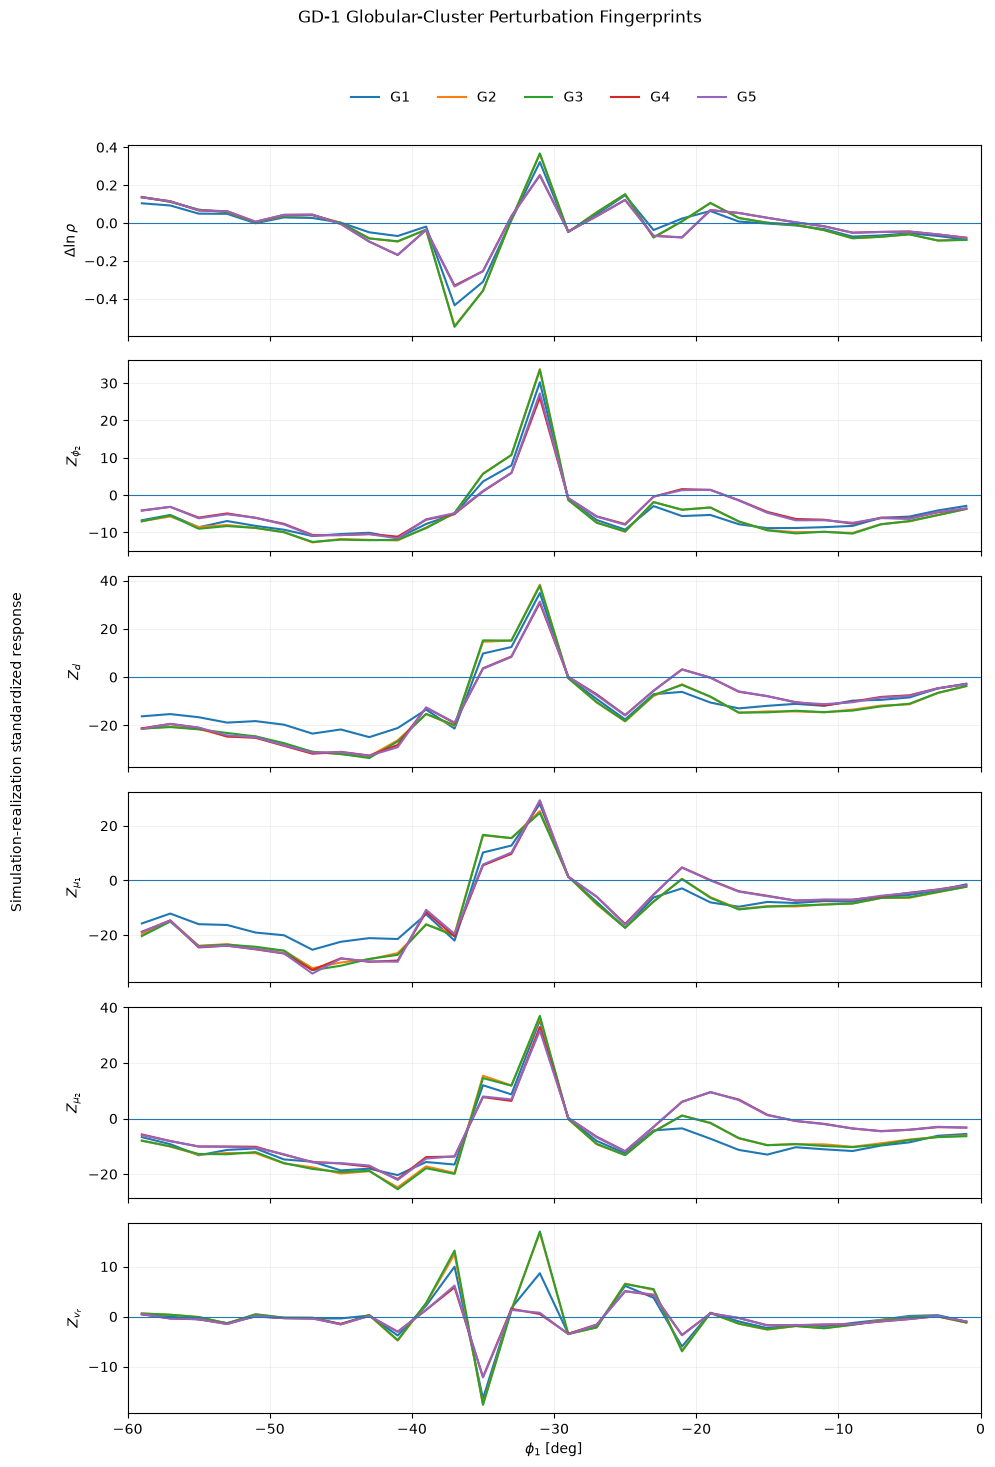

In [62]:
# ============================================================
# GC SIX-DIMENSIONAL FINGERPRINT
# ============================================================
#
# Production-level GC perturbation fingerprint.
#
# Panels:
#   1. Delta ln density
#   2. Z_phi2
#   3. Z_distance
#   4. Z_pm1
#   5. Z_pm2
#   6. Z_rv
#
# Z-values represent simulation-realization significance,
# not observational detection significance.
# ============================================================

import matplotlib.pyplot as plt


FIGURE_OBSERVABLES = [
    (
        r"$\Delta \ln \rho$",
        "delta_ln_density",
        None,
    ),
    (
        r"$Z_{\phi_2}$",
        "z_phi2",
        None,
    ),
    (
        r"$Z_d$",
        "z_distance",
        None,
    ),
    (
        r"$Z_{\mu_1}$",
        "z_pm1",
        None,
    ),
    (
        r"$Z_{\mu_2}$",
        "z_pm2",
        None,
    ),
    (
        r"$Z_{v_r}$",
        "z_rv",
        None,
    ),
]


fig, axes = plt.subplots(
    6,
    1,
    figsize=(10, 15),
    sharex=True,
)


for ax, (ylabel, key, _) in zip(
    axes,
    FIGURE_OBSERVABLES,
):

    for case in GC_STANDARDIZED_FINGERPRINTS:

        fingerprint = GC_STANDARDIZED_FINGERPRINTS[case]

        ax.plot(
            fingerprint["phi1_center_deg"],
            fingerprint[key],
            label=case,
            linewidth=1.5,
        )

    ax.axhline(
        0.0,
        linewidth=0.8,
    )

    ax.set_ylabel(ylabel)
    ax.grid(
        alpha=0.25,
        linewidth=0.5,
    )


# ------------------------------------------------------------
# Shared x-axis
# ------------------------------------------------------------

axes[-1].set_xlabel(
    r"$\phi_1$ [deg]"
)

axes[-1].set_xlim(
    PHI1_MIN,
    PHI1_MAX,
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

axes[0].legend(
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    frameon=False,
)


fig.suptitle(
    "GD-1 Globular-Cluster Perturbation Fingerprints",
    y=0.995,
)


fig.text(
    0.01,
    0.5,
    "Simulation-realization standardized response",
    va="center",
    rotation="vertical",
    fontsize=10,
)


fig.tight_layout(
    rect=[0.04, 0.02, 1.0, 0.97]
)


plt.show()

In [63]:
# ------------------------------------------------------------
# Save production fingerprint figure
# ------------------------------------------------------------

GC_FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "gc"
)

GC_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GC_FINGERPRINT_FIGURE = (
    GC_FIGURE_DIR
    / "gc_six_dimensional_fingerprint_192k.png"
)

fig.savefig(
    GC_FINGERPRINT_FIGURE,
    dpi=200,
    bbox_inches="tight",
)

print(
    f"Saved fingerprint figure:\n"
    f"  {GC_FINGERPRINT_FIGURE}"
)

Saved fingerprint figure:
  /home/darxsouls/research/stellar_streams/figures/gc/gc_six_dimensional_fingerprint_192k.png


1. The density response is concentrated around roughly $\phi_1\sim-40^\circ$ to $-20^\circ$, with a particularly clear depletion/enhancement pattern.
2. $\phi_2$, distance, and both proper-motion fingerprints show a strong common feature around $\phi_1\sim-35^\circ$ to $-30^\circ$.
3. $v_r$ has a somewhat different morphology, including sharper sign changes.
4. G1–G5 broadly track one another, while the amplitudes differ.
5. The fact that the responses extend well beyond the nominal $-500$ Myr encounter is physically reasonable: the perturbation is introduced at the encounter and subsequently propagates along the stream.

In [64]:
# ============================================================
# GC FINGERPRINT AMPLITUDES
# ============================================================
#
# Compact quantitative summaries of the GC fingerprints.
#
# Physical amplitudes:
#     peak_abs = max |Delta X|
#     RMS      = sqrt(mean(Delta X^2))
#
# Standardized amplitudes:
#     peak_abs_Z = max |Z_X|
#     RMS_Z      = sqrt(mean(Z_X^2))
#
# These are descriptive summaries only.
# ============================================================

AMPLITUDE_DEFINITIONS = {
    "density_log": {
        "response_key": "delta_ln_density",
        "z_key": None,
        "unit": "dimensionless",
    },

    "phi2_deg": {
        "response_key": "delta_phi2_deg",
        "z_key": "z_phi2",
        "unit": "deg",
    },

    "distance_kpc": {
        "response_key": "delta_distance_kpc",
        "z_key": "z_distance",
        "unit": "kpc",
    },

    "pm1_masyr": {
        "response_key": "delta_pm1_masyr",
        "z_key": "z_pm1",
        "unit": "mas/yr",
    },

    "pm2_masyr": {
        "response_key": "delta_pm2_masyr",
        "z_key": "z_pm2",
        "unit": "mas/yr",
    },

    "rv_kms": {
        "response_key": "delta_rv_kms",
        "z_key": "z_rv",
        "unit": "km/s",
    },
}


GC_FINGERPRINT_AMPLITUDES = {}


for case, fingerprint in GC_STANDARDIZED_FINGERPRINTS.items():

    amplitudes = {}

    for observable, definition in AMPLITUDE_DEFINITIONS.items():

        response = np.asarray(
            fingerprint[
                definition["response_key"]
            ],
            dtype=float,
        )

        valid = np.isfinite(response)

        if not np.any(valid):
            amplitudes[observable] = {
                "peak_abs": np.nan,
                "rms": np.nan,
                "peak_phi1_deg": np.nan,
                "signed_at_peak": np.nan,
                "unit": definition["unit"],
            }
            continue

        values = response[valid]
        phi1 = PHI1_CENTERS[valid]

        peak_index = np.argmax(
            np.abs(values)
        )

        amplitudes[observable] = {
            "peak_abs": float(
                np.abs(values[peak_index])
            ),

            "rms": float(
                np.sqrt(
                    np.mean(values**2)
                )
            ),

            "peak_phi1_deg": float(
                phi1[peak_index]
            ),

            "signed_at_peak": float(
                values[peak_index]
            ),

            "unit": definition["unit"],
        }

        # ----------------------------------------------------
        # Standardized amplitude
        # ----------------------------------------------------

        if definition["z_key"] is not None:

            z = np.asarray(
                fingerprint[
                    definition["z_key"]
                ],
                dtype=float,
            )

            z_valid = np.isfinite(z)

            if np.any(z_valid):

                amplitudes[observable][
                    "peak_abs_Z"
                ] = float(
                    np.max(
                        np.abs(z[z_valid])
                    )
                )

                amplitudes[observable][
                    "rms_Z"
                ] = float(
                    np.sqrt(
                        np.mean(
                            z[z_valid]**2
                        )
                    )
                )

    GC_FINGERPRINT_AMPLITUDES[case] = amplitudes


print("=" * 70)
print("GC FINGERPRINT AMPLITUDES")
print("=" * 70)

for case, amplitudes in GC_FINGERPRINT_AMPLITUDES.items():

    print(f"\n{case}")

    for observable, values in amplitudes.items():

        print(
            f"  {observable:15s} : "
            f"peak={values['peak_abs']:.6g} "
            f"{values['unit']}, "
            f"RMS={values['rms']:.6g} "
            f"{values['unit']}, "
            f"peak_phi1={values['peak_phi1_deg']:.1f} deg"
        )

        if "peak_abs_Z" in values:

            print(
                f"{'':20s}"
                f"peak|Z|={values['peak_abs_Z']:.3f}, "
                f"RMS(Z)={values['rms_Z']:.3f}"
            )

print("=" * 70)
print("GC fingerprint amplitude calculation: COMPLETE")
print("=" * 70)

GC FINGERPRINT AMPLITUDES

G1
  density_log     : peak=0.434138 dimensionless, RMS=0.126414 dimensionless, peak_phi1=-37.0 deg
  phi2_deg        : peak=0.130043 deg, RMS=0.0486087 deg, peak_phi1=-31.0 deg
                    peak|Z|=30.244, RMS(Z)=9.201
  distance_kpc    : peak=0.038031 kpc, RMS=0.0184702 kpc, peak_phi1=-31.0 deg
                    peak|Z|=34.818, RMS(Z)=15.794
  pm1_masyr       : peak=0.0628757 mas/yr, RMS=0.0347057 mas/yr, peak_phi1=-31.0 deg
                    peak|Z|=27.939, RMS(Z)=14.519
  pm2_masyr       : peak=0.0249176 mas/yr, RMS=0.00898414 mas/yr, peak_phi1=-31.0 deg
                    peak|Z|=35.398, RMS(Z)=13.275
  rv_kms          : peak=1.90056 km/s, RMS=0.462205 km/s, peak_phi1=-35.0 deg
                    peak|Z|=16.373, RMS(Z)=4.422

G2
  density_log     : peak=0.543688 dimensionless, RMS=0.152355 dimensionless, peak_phi1=-37.0 deg
  phi2_deg        : peak=0.136722 deg, RMS=0.0537305 deg, peak_phi1=-31.0 deg
                    peak|Z|=33.769, RMS(Z

In [67]:
# ============================================================
# GC FINGERPRINT AMPLITUDE TABLE
# ============================================================

AMPLITUDE_ROWS = []

for case, amplitudes in GC_FINGERPRINT_AMPLITUDES.items():

    row = {
        "case": case,
    }

    for observable, values in amplitudes.items():

        row[f"{observable}_peak"] = values[
            "peak_abs"
        ]

        row[f"{observable}_rms"] = values[
            "rms"
        ]

        row[f"{observable}_peak_phi1"] = values[
            "peak_phi1_deg"
        ]

        if "peak_abs_Z" in values:

            row[f"{observable}_peak_Z"] = values[
                "peak_abs_Z"
            ]

            row[f"{observable}_rms_Z"] = values[
                "rms_Z"
            ]

    AMPLITUDE_ROWS.append(row)


GC_AMPLITUDE_DF = pd.DataFrame(
    AMPLITUDE_ROWS
)

print("=" * 70)
print("GC FINGERPRINT AMPLITUDE TABLE")
print("=" * 70)

display(
    GC_AMPLITUDE_DF.round(6)
)

print("=" * 70)

GC FINGERPRINT AMPLITUDE TABLE


,case,density_log_peak,density_log_rms,density_log_peak_phi1,phi2_deg_peak,phi2_deg_rms,phi2_deg_peak_phi1,phi2_deg_peak_Z,phi2_deg_rms_Z,distance_kpc_peak,...,pm2_masyr_peak,pm2_masyr_rms,pm2_masyr_peak_phi1,pm2_masyr_peak_Z,pm2_masyr_rms_Z,rv_kms_peak,rv_kms_rms,rv_kms_peak_phi1,rv_kms_peak_Z,rv_kms_rms_Z
0,G1,0.434138,0.126414,-37.0,0.130043,0.048609,-31.0,30.243842,9.201150,0.038031,...,0.024918,0.008984,-31.0,35.398178,13.274523,1.900560,0.462205,-35.0,16.373051,4.422388
1,G2,0.543688,0.152355,-37.0,0.136722,0.053730,-31.0,33.768818,10.227271,0.037094,...,0.023727,0.009476,-31.0,36.281108,13.988229,2.195405,0.567664,-35.0,17.550951,5.593689
2,G3,0.547998,0.153025,-37.0,0.136423,0.053967,-31.0,33.551334,10.234522,0.036991,...,0.023691,0.009520,-31.0,36.981910,14.112482,2.183225,0.569004,-35.0,17.644077,5.690759
3,G4,0.329981,0.111709,-37.0,0.113487,0.042907,-31.0,26.136531,7.751825,0.034155,...,0.023750,0.007585,-31.0,32.966526,11.341020,1.529092,0.358655,-35.0,12.084097,3.080297
4,G5,0.335135,0.112403,-37.0,0.113781,0.043147,-31.0,27.264277,7.938358,0.034669,...,0.023767,0.007624,-31.0,31.674252,11.269218,1.558980,0.363828,-35.0,12.167347,3.126238


In [68]:
# ============================================================
# GC RESPONSE SHAPE COMPARISON
# ============================================================
#
# Compare the physical response curves between GC cases.
#
# Metrics:
#   correlation
#   RMS difference
#
# This describes response-shape similarity between cases.
# It is NOT a ranking of the GC cases.
# ============================================================

GC_CASES = list(
    GC_PRODUCTION_RESPONSES.keys()
)

RESPONSE_COMPARISON_KEYS = {
    "phi2_deg": "delta_phi2_deg",
    "distance_kpc": "delta_distance_kpc",
    "pm1_masyr": "delta_pm1_masyr",
    "pm2_masyr": "delta_pm2_masyr",
    "rv_kms": "delta_rv_kms",
    "density_log": "delta_ln_density",
}


def response_correlation(
    x,
    y,
):
    """
    Pearson correlation between two response profiles.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if np.count_nonzero(valid) < 2:
        return np.nan

    return float(
        np.corrcoef(
            x[valid],
            y[valid],
        )[0, 1]
    )


def response_rms_difference(
    x,
    y,
):
    """
    RMS difference between two response profiles.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if not np.any(valid):
        return np.nan

    return float(
        np.sqrt(
            np.mean(
                (x[valid] - y[valid])**2
            )
        )
    )


GC_RESPONSE_SHAPE_COMPARISON = {}


for observable, response_key in (
    RESPONSE_COMPARISON_KEYS.items()
):

    GC_RESPONSE_SHAPE_COMPARISON[
        observable
    ] = {}

    for i, case_i in enumerate(GC_CASES):

        for case_j in GC_CASES[i + 1:]:

            response_i = (
                GC_PRODUCTION_RESPONSES[
                    case_i
                ][response_key]
            )

            response_j = (
                GC_PRODUCTION_RESPONSES[
                    case_j
                ][response_key]
            )

            correlation = response_correlation(
                response_i,
                response_j,
            )

            rms = response_rms_difference(
                response_i,
                response_j,
            )

            GC_RESPONSE_SHAPE_COMPARISON[
                observable
            ][
                f"{case_i}_vs_{case_j}"
            ] = {
                "correlation": correlation,
                "rms": rms,
            }


print("=" * 70)
print("GC RESPONSE SHAPE COMPARISON")
print("=" * 70)

for observable, comparisons in (
    GC_RESPONSE_SHAPE_COMPARISON.items()
):

    print(f"\n{observable}")

    for pair, result in comparisons.items():

        print(
            f"  {pair:10s} : "
            f"correlation={result['correlation']: .5f}, "
            f"RMS={result['rms']:.6g}"
        )

print("=" * 70)
print("GC response-shape comparison: COMPLETE")
print("=" * 70)

GC RESPONSE SHAPE COMPARISON

phi2_deg
  G1_vs_G2   : correlation= 0.99199, RMS=0.0073325
  G1_vs_G3   : correlation= 0.99170, RMS=0.00757032
  G1_vs_G4   : correlation= 0.93908, RMS=0.0144287
  G1_vs_G5   : correlation= 0.94090, RMS=0.0141659
  G2_vs_G3   : correlation= 0.99997, RMS=0.0003906
  G2_vs_G4   : correlation= 0.96197, RMS=0.0154463
  G2_vs_G5   : correlation= 0.96366, RMS=0.015111
  G3_vs_G4   : correlation= 0.96131, RMS=0.015695
  G3_vs_G5   : correlation= 0.96302, RMS=0.0153591
  G4_vs_G5   : correlation= 0.99996, RMS=0.000398478

distance_kpc
  G1_vs_G2   : correlation= 0.98686, RMS=0.00459689
  G1_vs_G3   : correlation= 0.98685, RMS=0.00466442
  G1_vs_G4   : correlation= 0.92181, RMS=0.00560508
  G1_vs_G5   : correlation= 0.92381, RMS=0.00557961
  G2_vs_G3   : correlation= 0.99999, RMS=0.000103803
  G2_vs_G4   : correlation= 0.95408, RMS=0.00526524
  G2_vs_G5   : correlation= 0.95521, RMS=0.00518786
  G3_vs_G4   : correlation= 0.95336, RMS=0.00533992
  G3_vs_G5   : corr

In [69]:
# ============================================================
# GC RESPONSE SHAPE CORRELATION MATRICES
# ============================================================

GC_CORRELATION_MATRICES = {}


for observable, response_key in (
    RESPONSE_COMPARISON_KEYS.items()
):

    matrix = np.eye(
        len(GC_CASES),
        dtype=float,
    )

    for i, case_i in enumerate(GC_CASES):

        for j, case_j in enumerate(GC_CASES):

            if i == j:
                continue

            response_i = (
                GC_PRODUCTION_RESPONSES[
                    case_i
                ][response_key]
            )

            response_j = (
                GC_PRODUCTION_RESPONSES[
                    case_j
                ][response_key]
            )

            matrix[i, j] = (
                response_correlation(
                    response_i,
                    response_j,
                )
            )

    GC_CORRELATION_MATRICES[
        observable
    ] = matrix


for observable, matrix in (
    GC_CORRELATION_MATRICES.items()
):

    print("\n" + "=" * 70)
    print(
        f"{observable} correlation matrix"
    )
    print("=" * 70)

    display(
        pd.DataFrame(
            matrix,
            index=GC_CASES,
            columns=GC_CASES,
        ).round(4)
    )


phi2_deg correlation matrix


,G1,G2,G3,G4,G5
G1,1.0000,0.9920,0.9917,0.9391,0.9409
G2,0.9920,1.0000,1.0000,0.9620,0.9637
G3,0.9917,1.0000,1.0000,0.9613,0.9630
G4,0.9391,0.9620,0.9613,1.0000,1.0000
G5,0.9409,0.9637,0.9630,1.0000,1.0000



distance_kpc correlation matrix


,G1,G2,G3,G4,G5
G1,1.0000,0.9869,0.9868,0.9218,0.9238
G2,0.9869,1.0000,1.0000,0.9541,0.9552
G3,0.9868,1.0000,1.0000,0.9534,0.9545
G4,0.9218,0.9541,0.9534,1.0000,1.0000
G5,0.9238,0.9552,0.9545,1.0000,1.0000



pm1_masyr correlation matrix


...

,G1,G2,G3,G4,G5
G1,1.0000,0.9816,0.9815,0.8911,0.8936
G2,0.9816,1.0000,1.0000,0.9329,0.9357
G3,0.9815,1.0000,1.0000,0.9328,0.9356
G4,0.8911,0.9329,0.9328,1.0000,0.9999
G5,0.8936,0.9357,0.9356,0.9999,1.0000



rv_kms correlation matrix


,G1,G2,G3,G4,G5
G1,1.0000,0.9884,0.9873,0.9698,0.9719
G2,0.9884,1.0000,0.9999,0.9400,0.9441
G3,0.9873,0.9999,1.0000,0.9372,0.9415
G4,0.9698,0.9400,0.9372,1.0000,0.9996
G5,0.9719,0.9441,0.9415,0.9996,1.0000



density_log correlation matrix


,G1,G2,G3,G4,G5
G1,1.0000,0.9954,0.9955,0.9471,0.9490
G2,0.9954,1.0000,1.0000,0.9602,0.9619
G3,0.9955,1.0000,1.0000,0.9594,0.9611
G4,0.9471,0.9602,0.9594,1.0000,1.0000
G5,0.9490,0.9619,0.9611,1.0000,1.0000


In [80]:
# ============================================================
# GC RESPONSE EXPORT TABLE
# ============================================================
#
# Construct the GC response table in the same schema as the
# existing GMC phase-space response product.
# ============================================================

GC_RESPONSE_ROWS = []

for case in GC_CASES:

    response = GC_PRODUCTION_RESPONSES[case]

    for i, phi1 in enumerate(PHI1_CENTERS):

        GC_RESPONSE_ROWS.append({
            "case": case,
            "phi1_deg": phi1,

            "response_phi2_deg":
                response["delta_phi2_deg"][i],

            "response_distance_kpc":
                response["delta_distance_kpc"][i],

            "response_pm1_masyr":
                response["delta_pm1_masyr"][i],

            "response_pm2_masyr":
                response["delta_pm2_masyr"][i],

            "response_rv_kms":
                response["delta_rv_kms"][i],

            "response_density_log":
                response["delta_ln_density"][i],
        })


GC_RESPONSE_DF = pd.DataFrame(
    GC_RESPONSE_ROWS
)


print("=" * 70)
print("GC RESPONSE EXPORT TABLE")
print("=" * 70)

print(
    f"Rows      : {len(GC_RESPONSE_DF):,}"
)

print(
    f"Cases     : "
    f"{GC_RESPONSE_DF['case'].nunique()}"
)

print(
    f"Phi1 bins : "
    f"{GC_RESPONSE_DF['phi1_deg'].nunique()}"
)

print("\nColumns:")
for column in GC_RESPONSE_DF.columns:
    print(f"  {column}")

print("=" * 70)
print("GC response export table: READY")
print("=" * 70)

GC RESPONSE EXPORT TABLE
Rows      : 150
Cases     : 5
Phi1 bins : 30

Columns:
  case
  phi1_deg
  response_phi2_deg
  response_distance_kpc
  response_pm1_masyr
  response_pm2_masyr
  response_rv_kms
  response_density_log
GC response export table: READY


In [81]:
# ============================================================
# VALIDATE GC RESPONSE GRID
# ============================================================

for case in GC_CASES:

    subset = GC_RESPONSE_DF[
        GC_RESPONSE_DF["case"] == case
    ].sort_values("phi1_deg")

    phi1_values = (
        subset["phi1_deg"]
        .to_numpy()
    )

    assert np.array_equal(
        phi1_values,
        PHI1_CENTERS,
    )

    assert len(subset) == len(PHI1_CENTERS)

    for column in [
        "response_phi2_deg",
        "response_distance_kpc",
        "response_pm1_masyr",
        "response_pm2_masyr",
        "response_rv_kms",
        "response_density_log",
    ]:

        values = subset[column].to_numpy()

        assert values.size == len(PHI1_CENTERS)
        assert np.all(np.isfinite(values))


print("=" * 70)
print("GC RESPONSE GRID VALIDATION")
print("=" * 70)
print(
    "All GC cases: 30 identical phi1 bins"
)
print(
    "All response quantities: finite"
)
print("=" * 70)
print("GC response grid validation: PASS")
print("=" * 70)

GC RESPONSE GRID VALIDATION
All GC cases: 30 identical phi1 bins
All response quantities: finite
GC response grid validation: PASS


In [82]:
# ============================================================
# GC FROZEN PRODUCT EXPORT
# ============================================================
#
# Freeze the validated 192k GC perturbation products for
# downstream DM / GMC / GC comparison.
#
# Products:
#   - 5 GC production streams
#   - matched production control
#   - GD-1 observable profiles
#   - phase-space responses
#   - density responses
#   - bootstrap uncertainties
#   - standardized fingerprints
#   - fingerprint amplitudes
#   - response-shape comparisons
# ============================================================

GC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("=" * 80)
print("GC FROZEN PRODUCT EXPORT")
print("=" * 80)

print(f"Output directory:")
print(f"  {GC_DIR}")

# ------------------------------------------------------------
# Helper for stream serialization
# ------------------------------------------------------------

def stream_to_export_dict(stream):

    pos_kpc = stream.pos.xyz.to_value(
        u.kpc
    )

    vel_kpc_myr = stream.vel.d_xyz.to_value(
        u.kpc / u.Myr
    )

    release_time_myr = stream.release_time.to_value(
        u.Myr
    )

    lead_trail = np.asarray(
        stream.lead_trail
    )

    observables = mockstream_to_gd1(
        stream
    )

    return {
        "pos_kpc": np.asarray(
            pos_kpc,
            dtype=np.float64,
        ),

        "vel_kpc_myr": np.asarray(
            vel_kpc_myr,
            dtype=np.float64,
        ),

        "release_time_myr": np.asarray(
            release_time_myr,
            dtype=np.float64,
        ),

        "lead_trail": np.asarray(
            lead_trail,
        ),

        "phi1_deg": np.asarray(
            observables["phi1_deg"],
            dtype=np.float64,
        ),

        "phi2_deg": np.asarray(
            observables["phi2_deg"],
            dtype=np.float64,
        ),

        "distance_kpc": np.asarray(
            observables["distance_kpc"],
            dtype=np.float64,
        ),

        "pm1_masyr": np.asarray(
            observables["pm1_masyr"],
            dtype=np.float64,
        ),

        "pm2_masyr": np.asarray(
            observables["pm2_masyr"],
            dtype=np.float64,
        ),

        "rv_kms": np.asarray(
            observables["rv_kms"],
            dtype=np.float64,
        ),
    }


# ------------------------------------------------------------
# Export production control
# ------------------------------------------------------------

control_export = stream_to_export_dict(
    CONTROL_PRODUCTION_STREAM
)

control_file = (
    GC_DIR
    / "S_control_192k.npz"
)

np.savez_compressed(
    control_file,
    **control_export,
)

print(
    f"\nS_control exported:"
    f" {control_file.name}"
)


# ------------------------------------------------------------
# Export each GC production stream
# ------------------------------------------------------------

GC_STREAM_EXPORT_FILES = {}

for case in GC_CASES:

    stream = GC_PRODUCTION_STREAMS[
        case
    ]

    export_dict = stream_to_export_dict(
        stream
    )

    output_file = (
        GC_DIR
        / f"S_GC_{case}_192k.npz"
    )

    np.savez_compressed(
        output_file,
        **export_dict,
    )

    GC_STREAM_EXPORT_FILES[
        case
    ] = output_file

    print(
        f"{case} exported:"
        f" {output_file.name}"
    )


print("\nGC stream export: COMPLETE")

GC FROZEN PRODUCT EXPORT
Output directory:
  /home/darxsouls/research/stellar_streams/data/derived/gc_fingerprint_192k

S_control exported: S_control_192k.npz
G1 exported: S_GC_G1_192k.npz
G2 exported: S_GC_G2_192k.npz
G3 exported: S_GC_G3_192k.npz
G4 exported: S_GC_G4_192k.npz
G5 exported: S_GC_G5_192k.npz

GC stream export: COMPLETE


In [83]:
# ============================================================
# EXPORT GC PROFILE PRODUCTS
# ============================================================

PROFILE_ROWS = []

for case, profile in GC_PRODUCTION_PROFILES.items():

    for i in range(
        len(profile["phi1_center_deg"])
    ):

        row = {
            "case": case,

            "phi1_center_deg":
                profile["phi1_center_deg"][i],

            "phi1_lo_deg":
                profile["phi1_lo_deg"][i],

            "phi1_hi_deg":
                profile["phi1_hi_deg"][i],

            "n_total":
                profile["n_total"][i],
        }

        for key in PROFILE_KEYS:

            row[
                f"{key}_median"
            ] = profile[
                f"{key}_median"
            ][i]

            row[
                f"{key}_width"
            ] = profile[
                f"{key}_width"
            ][i]

            row[
                f"{key}_nvalid"
            ] = profile[
                f"{key}_nvalid"
            ][i]

        PROFILE_ROWS.append(row)


GC_PROFILES_DF = pd.DataFrame(
    PROFILE_ROWS
)

profile_file = (
    GC_DIR
    / "gc_profiles_192k.csv"
)

GC_PROFILES_DF.to_csv(
    profile_file,
    index=False,
)

print("=" * 80)
print("GC PROFILE EXPORT")
print("=" * 80)

print(
    f"Rows    : {len(GC_PROFILES_DF):,}"
)

print(
    f"Cases   : "
    f"{GC_PROFILES_DF['case'].nunique()}"
)

print(
    f"File    : {profile_file}"
)

print("=" * 80)

GC PROFILE EXPORT
Rows    : 180
Cases   : 6
File    : /home/darxsouls/research/stellar_streams/data/derived/gc_fingerprint_192k/gc_profiles_192k.csv


In [84]:
# ============================================================
# EXPORT GC RESPONSE PRODUCTS
# ============================================================

RESPONSE_EXPORT_ROWS = []

for case in GC_CASES:

    response = GC_PRODUCTION_RESPONSES[
        case
    ]

    uncertainty = GC_RESPONSE_UNCERTAINTIES[
        case
    ]

    fingerprint = (
        GC_STANDARDIZED_FINGERPRINTS[
            case
        ]
    )

    for i, phi1 in enumerate(
        PHI1_CENTERS
    ):

        RESPONSE_EXPORT_ROWS.append({

            "case": case,

            "phi1_deg": phi1,

            # ------------------------------------------------
            # Physical responses
            # ------------------------------------------------

            "response_density_log":
                response[
                    "delta_ln_density"
                ][i],

            "response_phi2_deg":
                response[
                    "delta_phi2_deg"
                ][i],

            "response_distance_kpc":
                response[
                    "delta_distance_kpc"
                ][i],

            "response_pm1_masyr":
                response[
                    "delta_pm1_masyr"
                ][i],

            "response_pm2_masyr":
                response[
                    "delta_pm2_masyr"
                ][i],

            "response_rv_kms":
                response[
                    "delta_rv_kms"
                ][i],

            # ------------------------------------------------
            # Width responses
            # ------------------------------------------------

            "response_phi2_width_deg":
                response[
                    "delta_phi2_width_deg"
                ][i],

            "response_distance_width_kpc":
                response[
                    "delta_distance_width_kpc"
                ][i],

            "response_pm1_width_masyr":
                response[
                    "delta_pm1_width_masyr"
                ][i],

            "response_pm2_width_masyr":
                response[
                    "delta_pm2_width_masyr"
                ][i],

            "response_rv_width_kms":
                response[
                    "delta_rv_width_kms"
                ][i],

            # ------------------------------------------------
            # Response uncertainties
            # ------------------------------------------------

            "sigma_phi2_deg":
                uncertainty[
                    "delta_phi2_deg_sigma"
                ][i],

            "sigma_distance_kpc":
                uncertainty[
                    "delta_distance_kpc_sigma"
                ][i],

            "sigma_pm1_masyr":
                uncertainty[
                    "delta_pm1_masyr_sigma"
                ][i],

            "sigma_pm2_masyr":
                uncertainty[
                    "delta_pm2_masyr_sigma"
                ][i],

            "sigma_rv_kms":
                uncertainty[
                    "delta_rv_kms_sigma"
                ][i],

            # ------------------------------------------------
            # Standardized fingerprints
            # ------------------------------------------------

            "z_phi2":
                fingerprint["z_phi2"][i],

            "z_distance":
                fingerprint["z_distance"][i],

            "z_pm1":
                fingerprint["z_pm1"][i],

            "z_pm2":
                fingerprint["z_pm2"][i],

            "z_rv":
                fingerprint["z_rv"][i],

            # ------------------------------------------------
            # Counts
            # ------------------------------------------------

            "n_control":
                response["n_control"][i],

            "n_perturbed":
                response["n_perturbed"][i],

            "n_control_phi2":
                response["n_control_phi2"][i],

            "n_perturbed_phi2":
                response["n_perturbed_phi2"][i],
        })


GC_FROZEN_RESPONSES_DF = pd.DataFrame(
    RESPONSE_EXPORT_ROWS
)

response_file = (
    GC_DIR
    / "gc_responses_192k.csv"
)

GC_FROZEN_RESPONSES_DF.to_csv(
    response_file,
    index=False,
)

print("=" * 80)
print("GC RESPONSE EXPORT")
print("=" * 80)

print(
    f"Rows      : "
    f"{len(GC_FROZEN_RESPONSES_DF):,}"
)

print(
    f"Cases     : "
    f"{GC_FROZEN_RESPONSES_DF['case'].nunique()}"
)

print(
    f"Columns   : "
    f"{len(GC_FROZEN_RESPONSES_DF.columns)}"
)

print(
    f"File      : {response_file}"
)

print("=" * 80)
print("GC response export: COMPLETE")

GC RESPONSE EXPORT
Rows      : 150
Cases     : 5
Columns   : 27
File      : /home/darxsouls/research/stellar_streams/data/derived/gc_fingerprint_192k/gc_responses_192k.csv
GC response export: COMPLETE


In [85]:
# ============================================================
# EXPORT GC AMPLITUDE AND SHAPE PRODUCTS
# ============================================================

# ------------------------------------------------------------
# Fingerprint amplitudes
# ------------------------------------------------------------

amplitude_file = (
    GC_DIR
    / "gc_fingerprint_amplitudes_192k.csv"
)

GC_AMPLITUDE_DF.to_csv(
    amplitude_file,
    index=False,
)


# ------------------------------------------------------------
# Response-shape comparison
# ------------------------------------------------------------

SHAPE_ROWS = []

for observable, comparisons in (
    GC_RESPONSE_SHAPE_COMPARISON.items()
):

    for pair, result in comparisons.items():

        case_a, case_b = pair.split(
            "_vs_"
        )

        SHAPE_ROWS.append({
            "observable": observable,
            "case_a": case_a,
            "case_b": case_b,
            "correlation":
                result["correlation"],
            "rms_difference":
                result["rms"],
        })


GC_SHAPE_DF = pd.DataFrame(
    SHAPE_ROWS
)

shape_file = (
    GC_DIR
    / "gc_response_shape_comparison_192k.csv"
)

GC_SHAPE_DF.to_csv(
    shape_file,
    index=False,
)


print("=" * 80)
print("GC SUMMARY PRODUCT EXPORT")
print("=" * 80)

print(
    f"Amplitude file : "
    f"{amplitude_file.name}"
)

print(
    f"Shape file     : "
    f"{shape_file.name}"
)

print(
    f"Shape rows     : "
    f"{len(GC_SHAPE_DF)}"
)

print("=" * 80)
print("GC summary product export: COMPLETE")
print("=" * 80)

GC SUMMARY PRODUCT EXPORT
Amplitude file : gc_fingerprint_amplitudes_192k.csv
Shape file     : gc_response_shape_comparison_192k.csv
Shape rows     : 60
GC summary product export: COMPLETE


In [86]:
# ============================================================
# GC FROZEN PRODUCT METADATA
# ============================================================

import json


def quantity_value(q, unit):
    return float(
        q.to_value(unit)
    )


metadata = {
    "project": "stellar_streams",

    "experiment": {
        "name": "GD-1 GC perturbation fingerprint",
        "notebook": "05_gc_perturbation_engine",
        "description": (
            "Production GD-1-like stellar-stream perturbations "
            "from compact Plummer globular-cluster perturbers."
        ),
    },

    "numerical_configuration": {
        "n_particles": int(N_PARTICLES),
        "dt_myr": quantity_value(DT, u.Myr),
        "release_cadence_myr":
            quantity_value(
                RELEASE_CADENCE,
                u.Myr,
            ),
        "stripping_duration_myr":
            quantity_value(
                T_STRIP,
                u.Myr,
            ),
        "integrator": "leapfrog",
        "random_seed": int(RNG_SEED),
    },

    "progenitor": {
        "mass_msun":
            quantity_value(
                M_PROG,
                u.Msun,
            ),
        "half_mass_radius_pc":
            quantity_value(
                R_HALF,
                u.pc,
            ),
        "plummer_b_pc":
            quantity_value(
                PLUMMER_B,
                u.pc,
            ),
    },

    "gd1_anchor": {
        "phi1_deg":
            quantity_value(
                ANCHOR_PHI1,
                u.deg,
            ),
        "phi2_deg":
            quantity_value(
                ANCHOR_PHI2,
                u.deg,
            ),
        "distance_kpc":
            quantity_value(
                ANCHOR_DISTANCE,
                u.kpc,
            ),
        "pm1_masyr":
            quantity_value(
                ANCHOR_PM1,
                u.mas / u.yr,
            ),
        "pm2_masyr":
            quantity_value(
                ANCHOR_PM2,
                u.mas / u.yr,
            ),
        "rv_kms":
            quantity_value(
                ANCHOR_RV,
                u.km / u.s,
            ),
    },

    "galactic_potential": {
        "name": "MilkyWayPotential",
        "version": "v2",
    },

    "encounter": {
        "relative_speed_kms":
            quantity_value(
                GC_REL_SPEED,
                u.km / u.s,
            ),
        "encounter_time_myr":
            quantity_value(
                GC_T_ENCOUNTER,
                u.Myr,
            ),
    },

    "gc_sweep": [],

    "analysis": {
        "phi1_min_deg": float(PHI1_MIN),
        "phi1_max_deg": float(PHI1_MAX),
        "phi1_bin_width_deg":
            float(PHI1_BIN_WIDTH),
        "n_phi1_bins":
            int(len(PHI1_CENTERS)),
        "bootstrap_realizations":
            int(N_BOOTSTRAP),
        "bootstrap_seed":
            int(BOOTSTRAP_RNG_SEED),
        "robust_width":
            "1.4826 * MAD",
        "density_response":
            "ln(N_GC / N_control)",
        "phase_space_response":
            "GC - matched control",
        "standardized_response":
            "Delta X / sigma_DeltaX",
        "standardized_response_interpretation":
            "simulation-realization significance only; "
            "not observational detection significance",
    },

    "files": {
        "control_stream":
            "S_control_192k.npz",
        "profiles":
            "gc_profiles_192k.csv",
        "responses":
            "gc_responses_192k.csv",
        "amplitudes":
            "gc_fingerprint_amplitudes_192k.csv",
        "shape_comparison":
            "gc_response_shape_comparison_192k.csv",
    },
}


# ------------------------------------------------------------
# GC parameter sweep
# ------------------------------------------------------------

for encounter in GC_ENCOUNTERS:

    metadata["gc_sweep"].append({
        "case":
            encounter["case"],

        "mass_msun":
            quantity_value(
                encounter["mass"],
                u.Msun,
            ),

        "plummer_scale_kpc":
            quantity_value(
                encounter["scale"],
                u.kpc,
            ),

        "impact_parameter_kpc":
            quantity_value(
                encounter["impact_parameter"],
                u.kpc,
            ),

        "impulse_ratio_to_dm":
            float(
                impulse_scale(
                    encounter["mass"],
                    encounter["impact_parameter"],
                    encounter["scale"],
                )
                / I_DM
            ),

        "stream_file":
            f"S_GC_{encounter['case']}_192k.npz",
    })


metadata_file = (
    GC_DIR
    / "metadata.json"
)

with open(
    metadata_file,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=2,
    )


print("=" * 80)
print("GC METADATA EXPORT")
print("=" * 80)

print(
    f"Metadata file:\n"
    f"  {metadata_file}"
)

print(
    f"GC cases: "
    f"{len(metadata['gc_sweep'])}"
)

print("=" * 80)
print("GC metadata export: COMPLETE")
print("=" * 80)

GC METADATA EXPORT
Metadata file:
  /home/darxsouls/research/stellar_streams/data/derived/gc_fingerprint_192k/metadata.json
GC cases: 5
GC metadata export: COMPLETE


In [87]:
# ============================================================
# VALIDATE FROZEN GC PRODUCTS
# ============================================================

print("=" * 80)
print("VALIDATING FROZEN GC PRODUCTS")
print("=" * 80)


# ------------------------------------------------------------
# Expected files
# ------------------------------------------------------------

expected_files = [
    GC_DIR / "S_control_192k.npz",
    GC_DIR / "gc_profiles_192k.csv",
    GC_DIR / "gc_responses_192k.csv",
    GC_DIR / "gc_fingerprint_amplitudes_192k.csv",
    GC_DIR / "gc_response_shape_comparison_192k.csv",
    GC_DIR / "metadata.json",
]

for case in GC_CASES:

    expected_files.append(
        GC_DIR / f"S_GC_{case}_192k.npz"
    )


# ------------------------------------------------------------
# File existence
# ------------------------------------------------------------

for path in expected_files:

    assert path.exists(), (
        f"Missing exported file: {path}"
    )

    assert path.stat().st_size > 0, (
        f"Empty exported file: {path}"
    )


print(
    f"Files present: "
    f"{len(expected_files)}/{len(expected_files)}"
)


# ------------------------------------------------------------
# Validate stream files
# ------------------------------------------------------------

stream_files = [
    GC_DIR / "S_control_192k.npz"
]

stream_files.extend(
    GC_DIR / f"S_GC_{case}_192k.npz"
    for case in GC_CASES
)


for path in stream_files:

    print(f"\nChecking: {path.name}")

    with np.load(
        path,
        allow_pickle=False,
    ) as data:

        required_keys = [
            "pos_kpc",
            "vel_kpc_myr",
            "release_time_myr",
            "lead_trail",
            "phi1_deg",
            "phi2_deg",
            "distance_kpc",
            "pm1_masyr",
            "pm2_masyr",
            "rv_kms",
        ]

        for key in required_keys:
            assert key in data.files, (
                f"Missing key '{key}' "
                f"in {path.name}"
            )

        # ----------------------------------------------------
        # Particle count is defined by the 1-D observable
        # arrays.
        # ----------------------------------------------------

        n = data["phi1_deg"].size

        assert n == PROD_N_PARTICLES, (
            f"{path.name}: expected "
            f"{PROD_N_PARTICLES} particles, "
            f"got {n}"
        )

        # ----------------------------------------------------
        # Vector phase-space arrays
        # ----------------------------------------------------

        pos = np.asarray(
            data["pos_kpc"]
        )

        vel = np.asarray(
            data["vel_kpc_myr"]
        )

        assert pos.shape == (
            3,
            n,
        ), (
            f"{path.name}: unexpected "
            f"pos shape {pos.shape}"
        )

        assert vel.shape == (
            3,
            n,
        ), (
            f"{path.name}: unexpected "
            f"vel shape {vel.shape}"
        )

        # ----------------------------------------------------
        # One value per particle arrays
        # ----------------------------------------------------

        one_dimensional_keys = [
            "release_time_myr",
            "lead_trail",
            "phi1_deg",
            "phi2_deg",
            "distance_kpc",
            "pm1_masyr",
            "pm2_masyr",
            "rv_kms",
        ]

        for key in one_dimensional_keys:

            arr = np.asarray(
                data[key]
            )

            assert arr.size == n, (
                f"{path.name}: {key} has "
                f"{arr.size} values; "
                f"expected {n}"
            )

            assert arr.ndim == 1, (
                f"{path.name}: {key} has "
                f"unexpected shape {arr.shape}"
            )

        # ----------------------------------------------------
        # Finite numerical values
        # ----------------------------------------------------

        assert np.isfinite(pos).all(), (
            f"Non-finite positions in "
            f"{path.name}"
        )

        assert np.isfinite(vel).all(), (
            f"Non-finite velocities in "
            f"{path.name}"
        )

        numerical_keys = [
            "release_time_myr",
            "phi1_deg",
            "phi2_deg",
            "distance_kpc",
            "pm1_masyr",
            "pm2_masyr",
            "rv_kms",
        ]

        for key in numerical_keys:

            arr = np.asarray(
                data[key]
            )

            assert np.isfinite(arr).all(), (
                f"Non-finite values in "
                f"{path.name}: {key}"
            )

        print(
            f"  particles : {n:,}"
        )

        print(
            f"  position  : {pos.shape}"
        )

        print(
            f"  velocity  : {vel.shape}"
        )

        print(
            f"  finite    : PASS"
        )


# ------------------------------------------------------------
# Validate CSV products
# ------------------------------------------------------------

profiles_check = pd.read_csv(
    GC_DIR / "gc_profiles_192k.csv"
)

responses_check = pd.read_csv(
    GC_DIR / "gc_responses_192k.csv"
)

amplitudes_check = pd.read_csv(
    GC_DIR / "gc_fingerprint_amplitudes_192k.csv"
)

shape_check = pd.read_csv(
    GC_DIR / "gc_response_shape_comparison_192k.csv"
)


assert len(profiles_check) == 180
assert profiles_check["case"].nunique() == 6

assert len(responses_check) == 150
assert responses_check["case"].nunique() == 5

assert len(amplitudes_check) == 5

assert len(shape_check) == 60


# ------------------------------------------------------------
# Validate metadata
# ------------------------------------------------------------

with open(
    GC_DIR / "metadata.json",
    "r",
    encoding="utf-8",
) as f:

    metadata_check = json.load(f)


assert len(
    metadata_check["gc_sweep"]
) == 5

assert (
    metadata_check["numerical_configuration"]
    ["n_particles"]
    == PROD_N_PARTICLES
)


print("\nStream products : PASS")
print("Profile product : PASS")
print("Response product: PASS")
print("Amplitude product: PASS")
print("Shape comparison: PASS")
print("Metadata        : PASS")

print("=" * 80)
print("FROZEN GC PRODUCT VALIDATION: PASS")
print("=" * 80)

VALIDATING FROZEN GC PRODUCTS
Files present: 11/11

Checking: S_control_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Checking: S_GC_G1_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Checking: S_GC_G2_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Checking: S_GC_G3_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Checking: S_GC_G4_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Checking: S_GC_G5_192k.npz
  particles : 192,064
  position  : (3, 192064)
  velocity  : (3, 192064)
  finite    : PASS

Stream products : PASS
Profile product : PASS
Response product: PASS
Amplitude product: PASS
Shape comparison: PASS
Metadata        : PASS
FROZEN GC PRODUCT VALIDATION: PASS


In [88]:
# ============================================================
# GC PRODUCT FILE SIZES
# ============================================================

print("=" * 80)
print("GC PRODUCT FILE SIZES")
print("=" * 80)


for path in sorted(
    GC_DIR.iterdir()
):

    if path.is_file():

        size_mb = (
            path.stat().st_size
            / (1024**2)
        )

        print(
            f"{path.name:45s} "
            f"{size_mb:10.2f} MB"
        )


print("=" * 80)

GC PRODUCT FILE SIZES
S_GC_G1_192k.npz                                   16.20 MB
S_GC_G2_192k.npz                                   16.20 MB
S_GC_G3_192k.npz                                   16.20 MB
S_GC_G4_192k.npz                                   16.20 MB
S_GC_G5_192k.npz                                   16.20 MB
S_control_192k.npz                                 16.19 MB
gc_fingerprint_amplitudes_192k.csv                  0.00 MB
gc_profiles_192k.csv                                0.04 MB
gc_response_shape_comparison_192k.csv               0.00 MB
gc_responses_192k.csv                               0.07 MB
metadata.json                                       0.00 MB
